# Machine Learning Project

**Note**: This project is done in the Jupyter Notebook.

## **Contents**
- <a href= #link0>Exploratory Data Analysis</a>
- <a href= #link1>Data Preprocessing</a>
- <a href= #link2>Model Building</a>
- <a href= #link3>Model Performance Improvement</a>
- <a href= #link4>Model Performance Comparison and Final Model Selection</a>
- <a href= #link5>Actionable Insights & Recommendations</a>

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    accuracy_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    auc,
    classification_report
)

# Data Overview

**Data Loading**

In [7]:
INN = pd.read_csv('INNHotelsGroup.csv')

**Creating a copy of the data**

In [9]:
data = INN.copy()

**Data Overview**

In [11]:
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [12]:
print("The number of rows in data:", data.shape[0], "\nThe number of columns in data:", data.shape[1])

The number of rows in data: 36275 
The number of columns in data: 19


**Dataframe Information**

In [6]:
data.info()

NameError: name 'data' is not defined

**Duplicate Rows**

In [16]:
data.duplicated().sum()

0

There are no duplicated rows in the dataset.

**Checking Missing Values**

In [19]:
data.isnull().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

There are no Missing values in the dataset.

**Booking ID**

In [22]:
data['Booking_ID'].nunique

<bound method IndexOpsMixin.nunique of 0        INN00001
1        INN00002
2        INN00003
3        INN00004
4        INN00005
           ...   
36270    INN36271
36271    INN36272
36272    INN36273
36273    INN36274
36274    INN36275
Name: Booking_ID, Length: 36275, dtype: object>

- It is the unique identifier of each booking, so we can drop this column.

In [24]:
data = data.drop(['Booking_ID'], axis= 1)

In [25]:
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled



**Numerical Column of unique values**

In [27]:
features = data.select_dtypes(include=['number']).columns.to_list()

for i, feature in enumerate(features):
    print(data[feature].value_counts())
    print('---------------------------------------------')

no_of_adults
2    26108
1     7695
3     2317
0      139
4       16
Name: count, dtype: int64
---------------------------------------------
no_of_children
0     33577
1      1618
2      1058
3        19
9         2
10        1
Name: count, dtype: int64
---------------------------------------------
no_of_weekend_nights
0    16872
1     9995
2     9071
3      153
4      129
5       34
6       20
7        1
Name: count, dtype: int64
---------------------------------------------
no_of_week_nights
2     11444
1      9488
3      7839
4      2990
0      2387
5      1614
6       189
7       113
10       62
8        62
9        34
11       17
15       10
12        9
14        7
13        5
17        3
16        2
Name: count, dtype: int64
---------------------------------------------
required_car_parking_space
0    35151
1     1124
Name: count, dtype: int64
---------------------------------------------
lead_time
0      1297
1      1078
2       643
3       630
4       628
       ... 
300       1

**Categorical Column of unique values**

In [29]:
features = data.select_dtypes(include=['object']).columns.to_list()

for i, feature in enumerate(features):
    print(data[feature].value_counts())
    print('---------------------------------------------')

type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64
---------------------------------------------
room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64
---------------------------------------------
market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64
---------------------------------------------
booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64
---------------------------------------------


**Target Column**

In [31]:
data.groupby('booking_status').count()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
booking_status,,,,,,,,,,,,,,,,,
Canceled,11885,11885,11885,11885,11885,11885,11885,11885,11885,11885,11885,11885,11885,11885,11885,11885,11885
Not_Canceled,24390,24390,24390,24390,24390,24390,24390,24390,24390,24390,24390,24390,24390,24390,24390,24390,24390


**Statistical Summary**

In [33]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.0,1.844962,0.518715,0.0,2.0,2.00,2.0,4.0
no_of_children,36275.0,0.105279,0.402648,0.0,0.0,0.00,0.0,10.0
no_of_weekend_nights,36275.0,0.810724,0.870644,0.0,0.0,1.00,2.0,7.0
no_of_week_nights,36275.0,2.204300,1.410905,0.0,1.0,2.00,3.0,17.0
required_car_parking_space,36275.0,0.030986,0.173281,0.0,0.0,0.00,0.0,1.0
lead_time,36275.0,85.232557,85.930817,0.0,17.0,57.00,126.0,443.0
arrival_year,36275.0,2017.820427,0.383836,2017.0,2018.0,2018.00,2018.0,2018.0
arrival_month,36275.0,7.423653,3.069894,1.0,5.0,8.00,10.0,12.0
arrival_date,36275.0,15.596995,8.740447,1.0,8.0,16.00,23.0,31.0
repeated_guest,36275.0,0.025637,0.158053,0.0,0.0,0.00,0.0,1.0


# <a name=link0>Exploratory Data Analysis</a>

## Univariate Analysis

### Function for Hist and Box plot

In [37]:
def hist_box(df, col,figsize=(8, 7)):
    fig, axes = plt.subplots(2, 1, figsize=figsize) 
    # Histplot
    sns.histplot(data= df, x= col, ax= axes[0])
    plt.title(col)
    plt.xlabel(col)

    # Boxplot
    sns.boxplot(data= df, x= col, ax= axes[1])
    plt.title(col)
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

### Number of adults

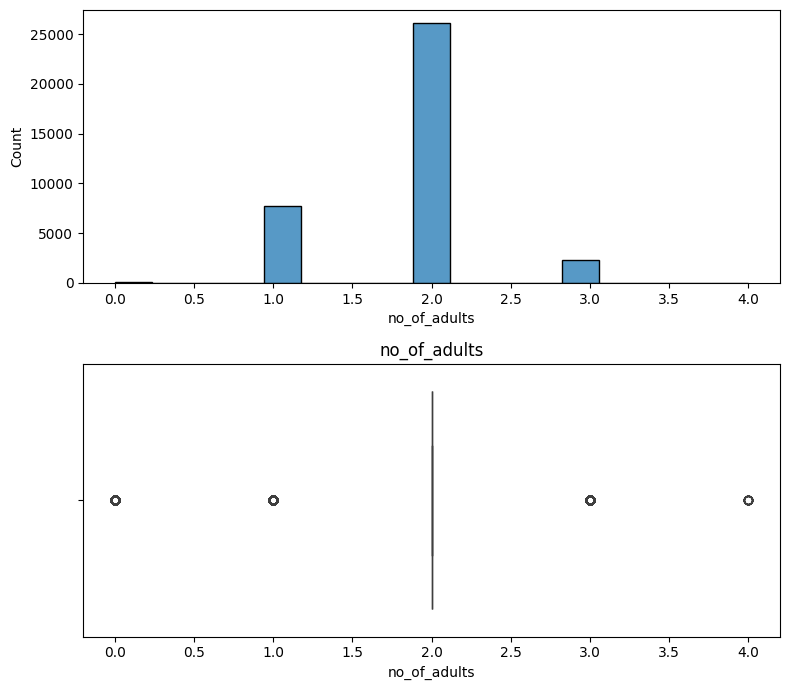

In [39]:
hist_box(data, 'no_of_adults')

**Histogram:** Most bookings are made for 2 adults.

**Boxplot:** There are some outliers for adults.

### Number of weekend nights (Saturday or Sunday)

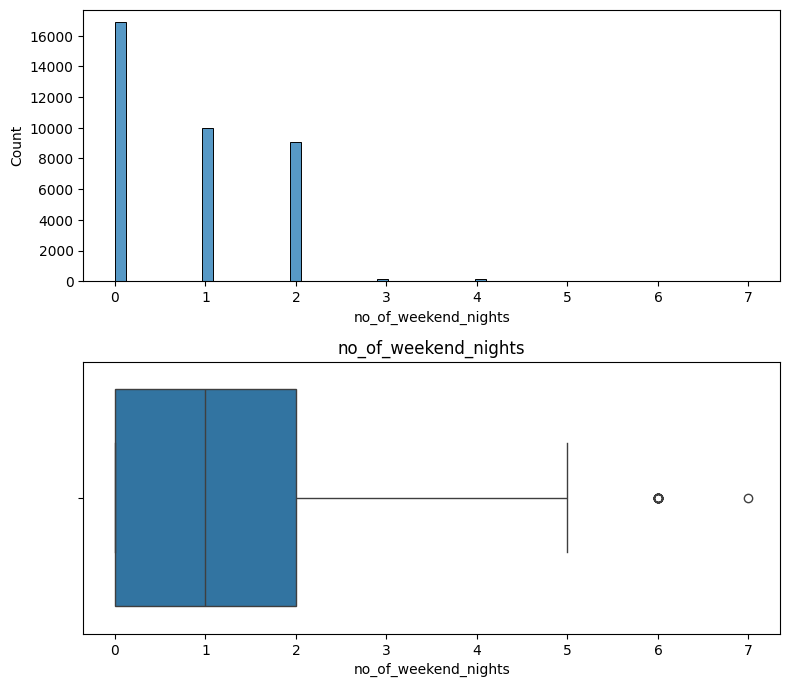

In [42]:
hist_box(data, 'no_of_weekend_nights')

**Histogram:** Most bookings include 0 or 2 weekend nights.

**Boxplot:** There are some outliers for weekend nights.

### Number of weeknights (Monday to Friday)

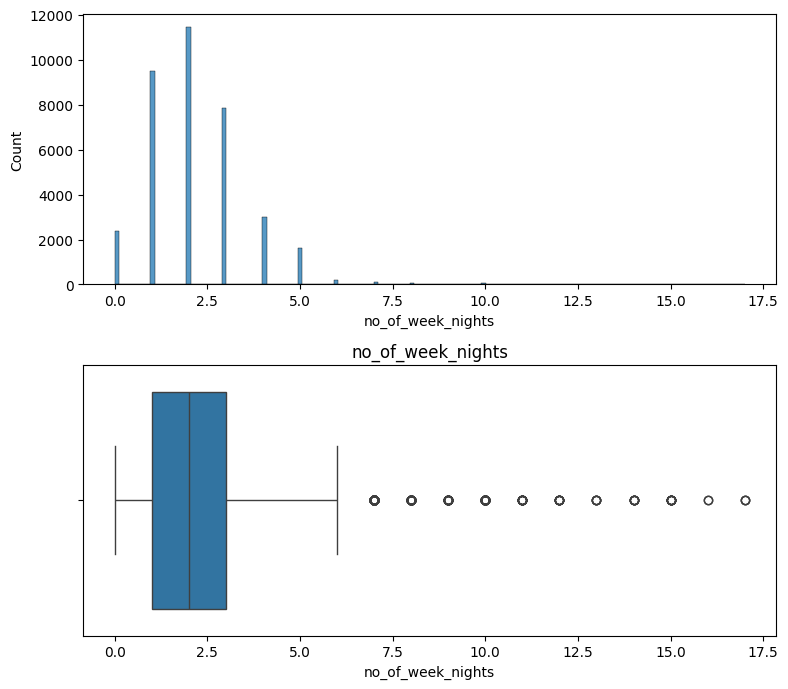

In [45]:
hist_box(data, 'no_of_week_nights')

**Histogram:** Most bookings include 2 or 3 week nights.

**Boxplot:** There are some outliers with higher numbers of week nights.

### Number of days between the date of booking and the arrival date (Lead time)

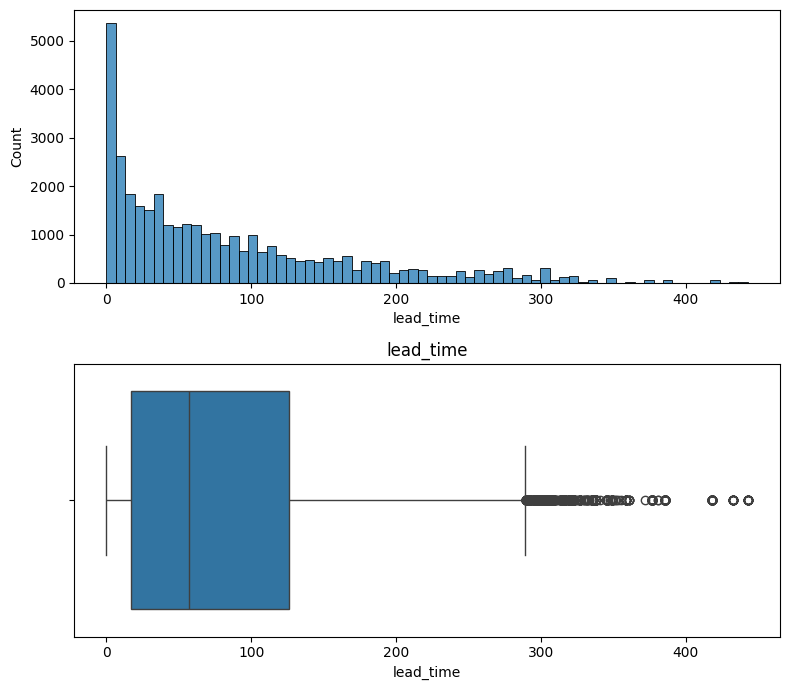

In [48]:
hist_box(data, 'lead_time')

**Histogram:** Right-skewed distribution with most bookings having a lead time of less than 100 days.

**Boxplot:** Significant outliers with very high lead times.

### Month of arrival date

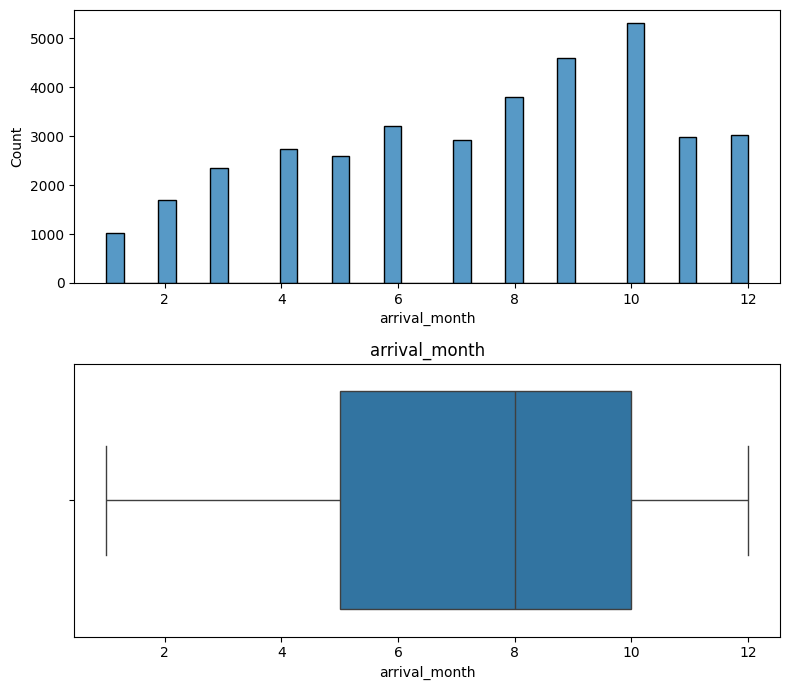

In [51]:
hist_box(data, 'arrival_month')

**Histogram:** Bookings are relatively evenly distributed across the months.

**Boxplot:** No significant outliers.

### Date of the month

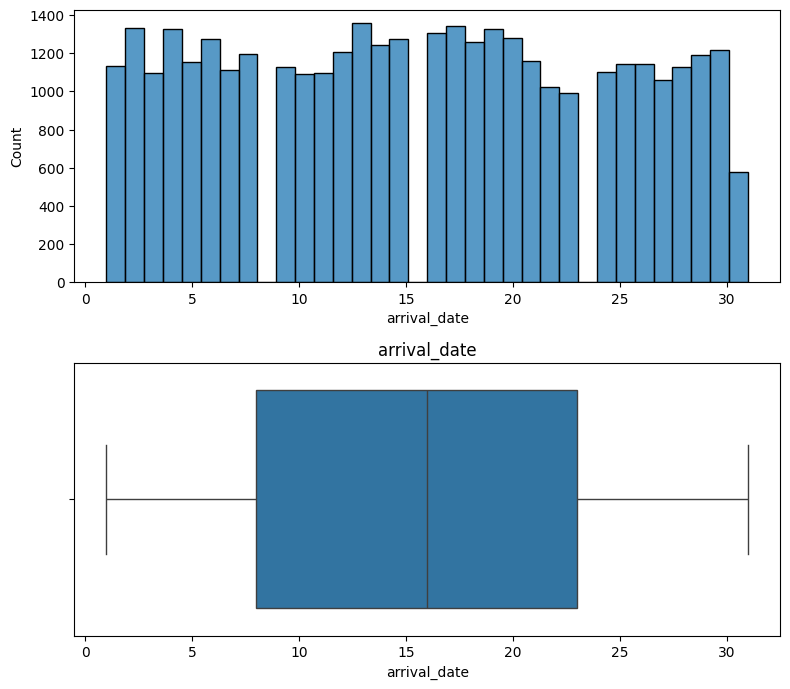

In [54]:
hist_box(data, 'arrival_date')

**Histogram:** Bookings are relatively evenly distributed across the dates.

**Boxplot:** No significant outliers.

### Average price per day of the reservation

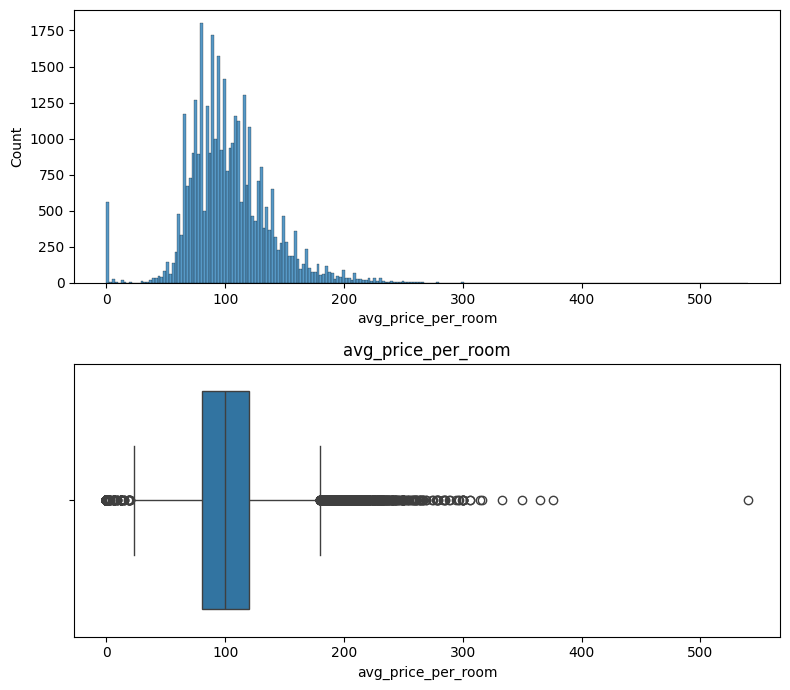

In [57]:
hist_box(data, 'avg_price_per_room')

**Histogram:** Right-skewed distribution with most bookings having an average price per room between 50 and 150.

**Boxplot:** Significant outliers with very high average prices.

### Total number of special requests made by the customer

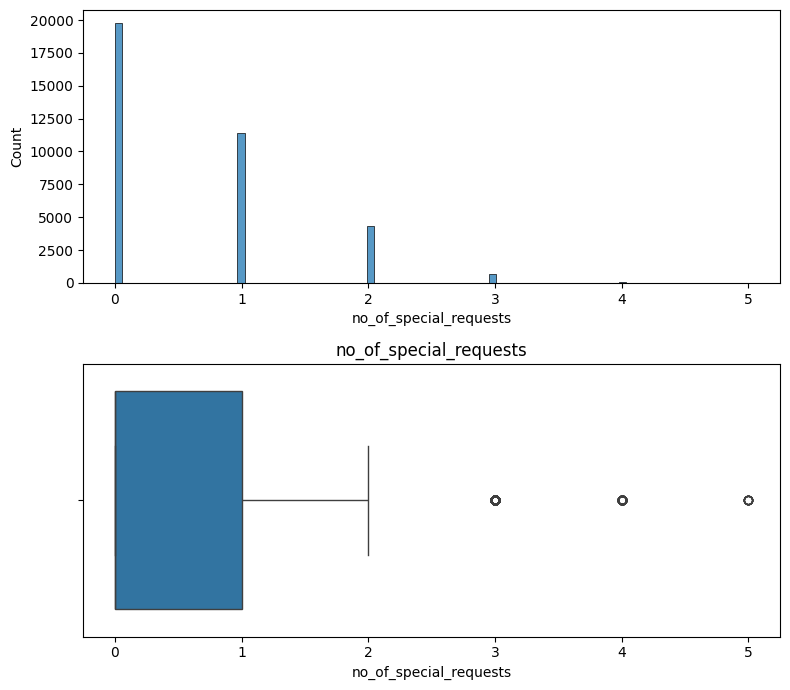

In [60]:
hist_box(data, 'no_of_special_requests')

**Histogram:** Most bookings have 0 or 1 special requests.

**Boxplot:** There are some outliers with higher numbers of special requests.

### Type of meal plan booked by the customer

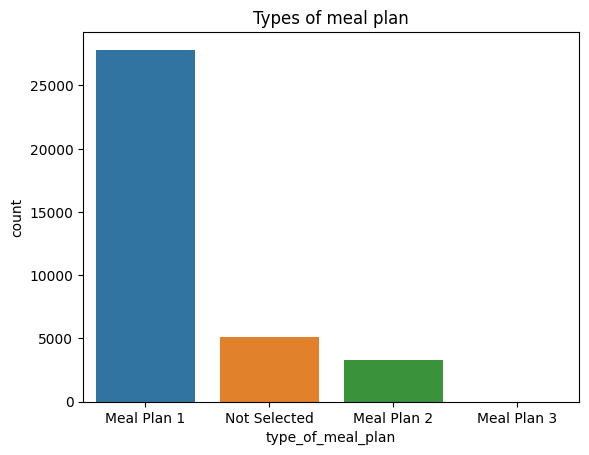

In [63]:
sns.countplot(data= data, x='type_of_meal_plan', hue='type_of_meal_plan')
plt.title('Types of meal plan');

**Count Plot:** "Meal Plan 1" is the most popular meal plan among the bookings.

### Type of room reserved by the customer

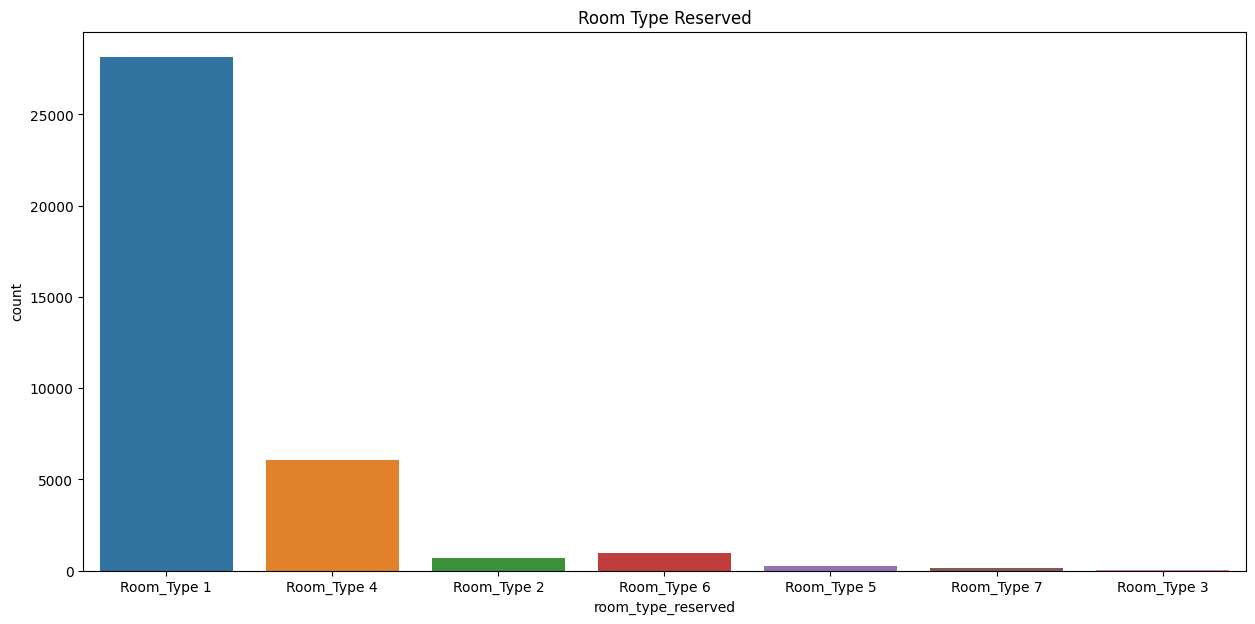

In [66]:
plt.figure(figsize=(15,7))
sns.countplot(data= data, x='room_type_reserved', hue='room_type_reserved')
plt.title('Room Type Reserved');

**Count Plot:** "Room Type 1" is the most popular room type among the bookings.

### Market segment

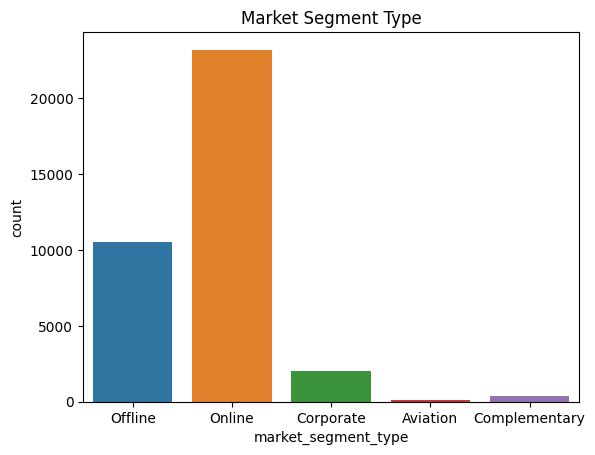

In [69]:
sns.countplot(data= data, x='market_segment_type', hue='market_segment_type')
plt.title('Market Segment Type');

**Count Plot:** "Online" is the most popular market segment type among the bookings.

### Booking Status

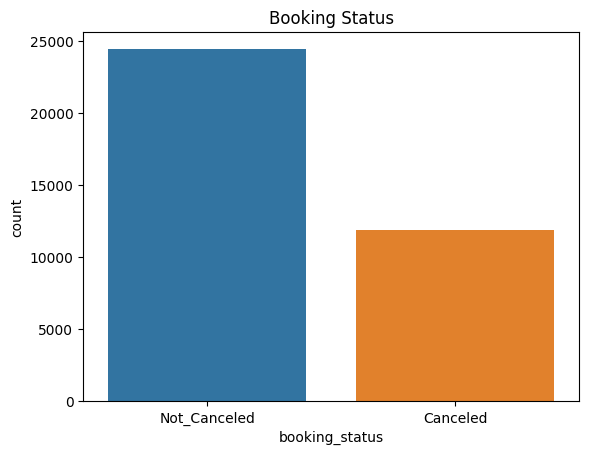

In [72]:
sns.countplot(data= data, x= 'booking_status', hue= 'booking_status')
plt.title('Booking Status');

**Count Plot:** "Not Canceled" is the most common booking status among the bookings.

## Bivariate Analysis

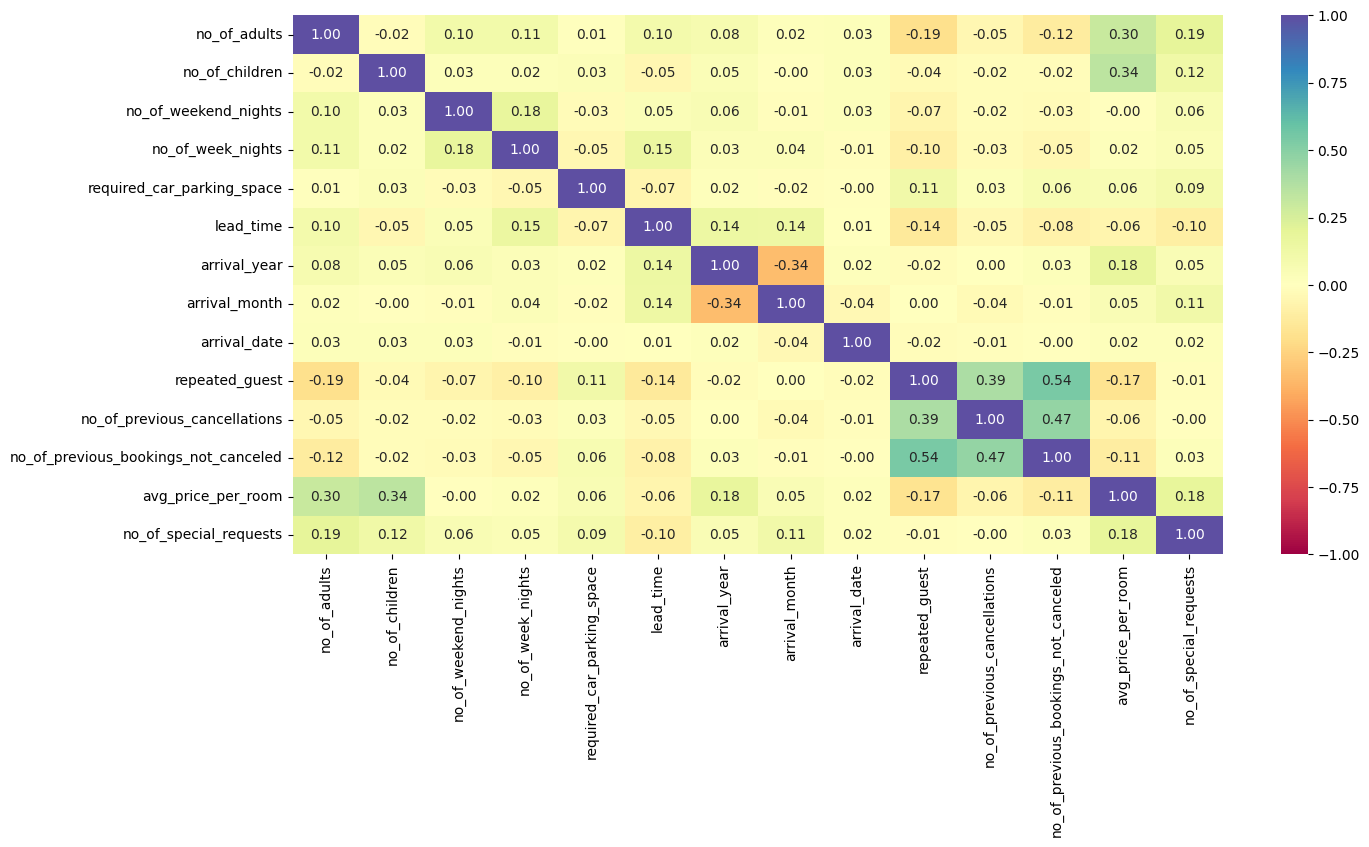

In [75]:
plt.figure(figsize=(15, 7))
features = data.select_dtypes(include=np.number).columns.to_list()
sns.heatmap(data[features].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f",cmap="Spectral")
plt.show()

### Types of meal plan vs booking_status

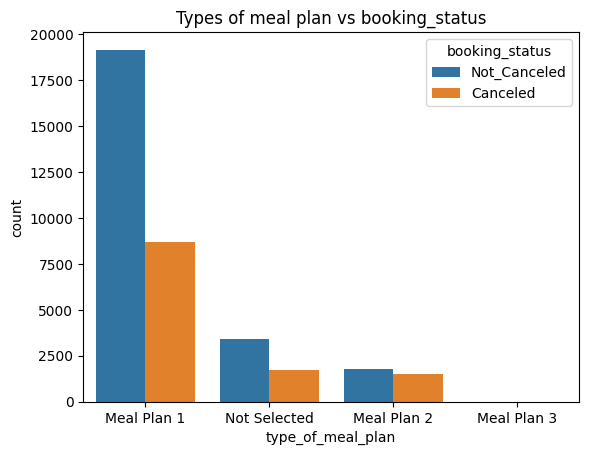

In [77]:
sns.countplot(data=data, x='type_of_meal_plan', hue='booking_status')
plt.title('Types of meal plan vs booking_status')
plt.show()

**Count Plot:** 

- The count plot shows that "Meal Plan 1" has the highest number of bookings, both canceled and not canceled.- 
"Not Selected" meal plan has a higher proportion of canceled bookings compared to other meal plans.

### Room Type Reserved vs booking_status

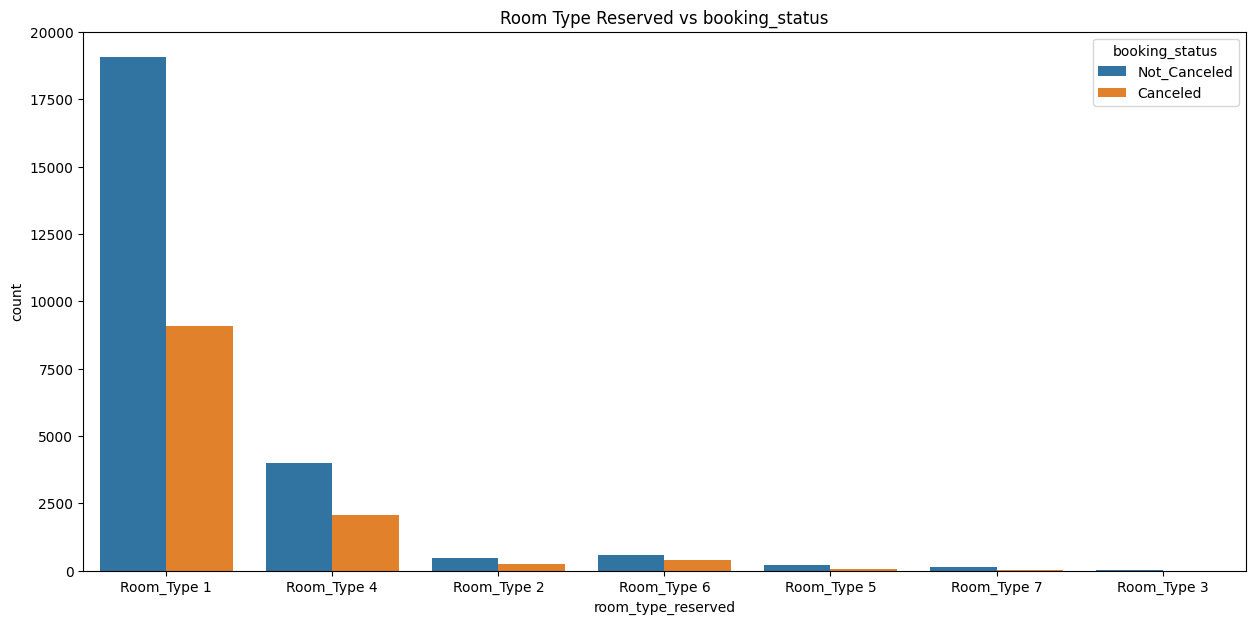

In [80]:
plt.figure(figsize=(15,7))
sns.countplot(data=data, x='room_type_reserved', hue='booking_status')
plt.title('Room Type Reserved vs booking_status')
plt.show()

**Count Plot:** 

- The count plot shows that "Room type 1" has the highest number of bookings, both canceled and not canceled.- 
"Room type 1" market segment has a higher proportion of not canceled bookings compared to other market segments.

### Market Segment vs booking_status

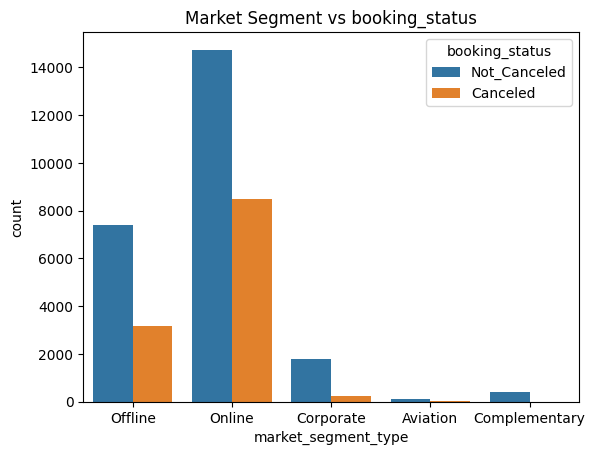

In [83]:
sns.countplot(data=data, x='market_segment_type', hue='booking_status')
plt.title('Market Segment vs booking_status')
plt.show()

**Count Plot:** 

- The count plot shows that "Online" market segment has the highest number of bookings, both canceled and not canceled.

### Booking_status vs Numerical Columns

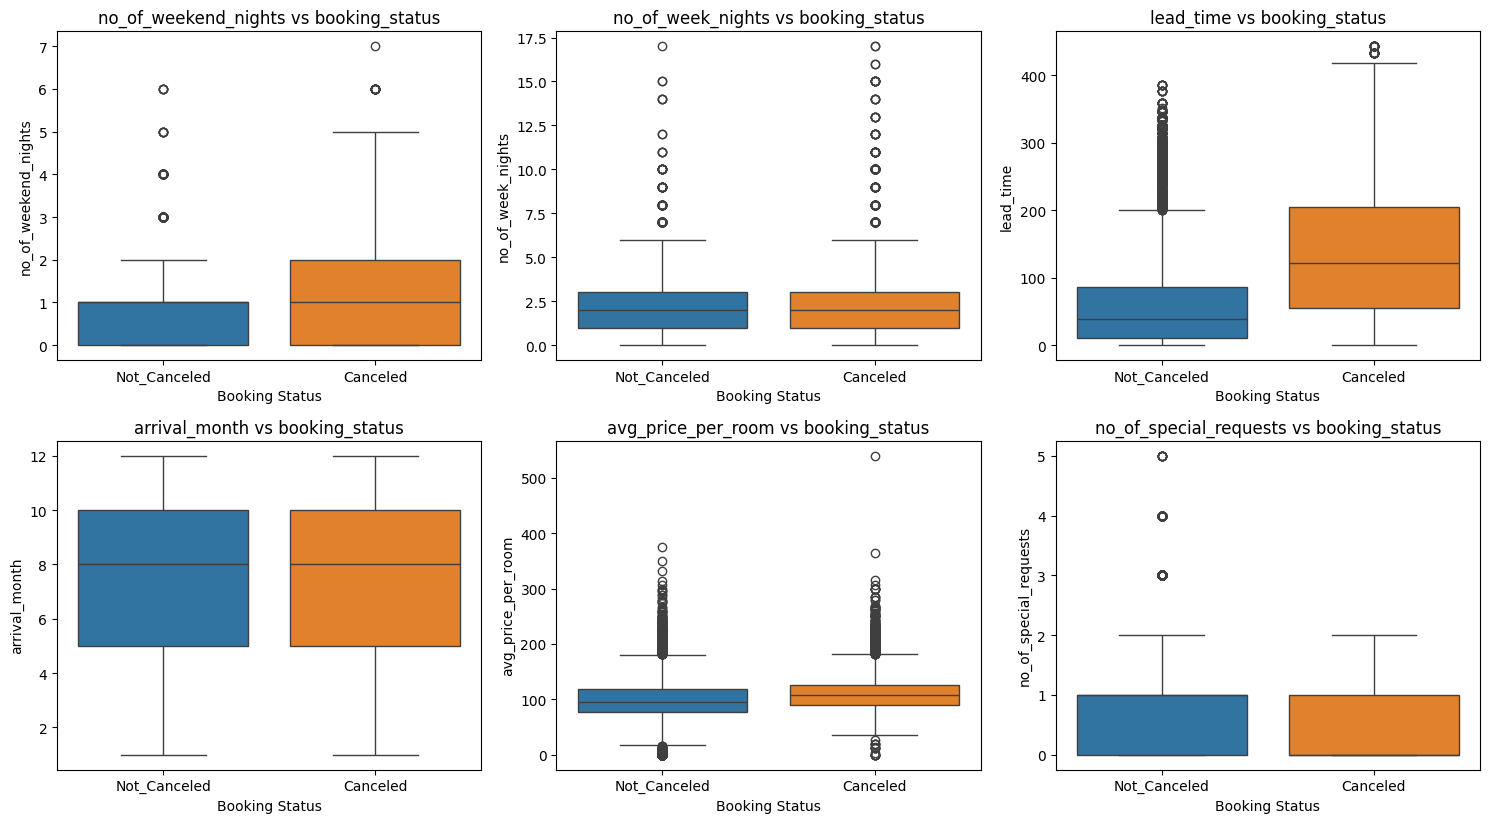

In [86]:
plt.figure(figsize=(15, 12))
categorical_columns = ['no_of_weekend_nights','no_of_week_nights','lead_time','arrival_month','avg_price_per_room','no_of_special_requests']
for i, column in enumerate(categorical_columns):
    plt.subplot(3,3, i+1)
    sns.boxplot(data=data, x= 'booking_status', y=column ,hue='booking_status')
    plt.title(f'{column} vs booking_status')
    plt.xlabel('Booking Status')
    plt.ylabel(column)
    
plt.tight_layout()
plt.show()

## EDA Questions and Answers

In [88]:
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


#### **1. What are the busiest months in the hotel?**

In [90]:
a = data['arrival_month'].value_counts()
print(a)

arrival_month
10    5317
9     4611
8     3813
6     3203
12    3021
11    2980
7     2920
4     2736
5     2598
3     2358
2     1704
1     1014
Name: count, dtype: int64


**Observation**: The Busiest months in the hotel are as follows:
- October – 5,317 bookings
- September – 4,611 bookings
- August – 3,813 bookings
  
**Insight**: The number of bookings for each month, with October being the busiest month followed by September and August.


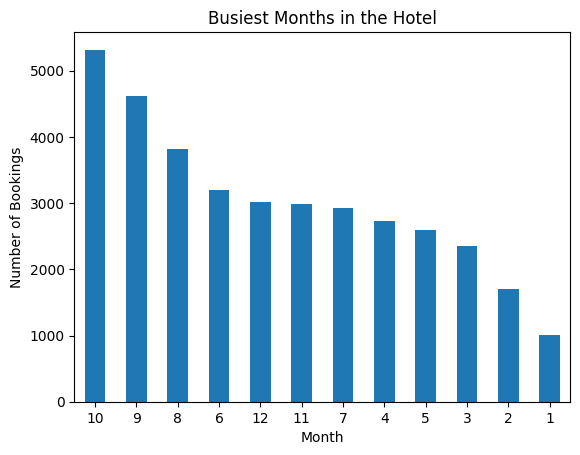

In [92]:
a.plot(kind='bar')
plt.title('Busiest Months in the Hotel')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=360)
plt.show()

#### **2. Which market segment do most of the guests come from?**

In [94]:
b = data['market_segment_type'].value_counts(normalize= True)*100
print(b)

market_segment_type
Online           63.994487
Offline          29.022743
Corporate         5.560303
Complementary     1.077877
Aviation          0.344590
Name: proportion, dtype: float64


**Observation**: The Market segment for the majority of the guests is the **Online** segment, with **64%**.

**Insight**: Online segments play a crucial role in driving bookings for INN Hotels Group.


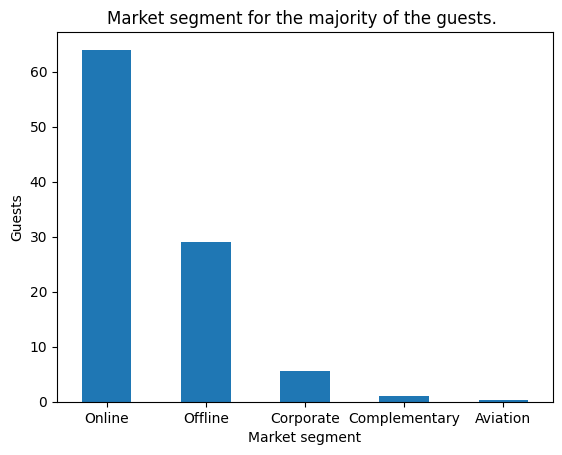

In [96]:
b.plot(kind='bar')
plt.title('Market segment for the majority of the guests. ')
plt.xlabel('Market segment')
plt.ylabel('Guests')
plt.xticks(rotation=360)
plt.show()

#### **3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?**

In [98]:
data.groupby(['market_segment_type'])['avg_price_per_room'].describe()

,count,mean,std,min,25%,50%,75%,max
market_segment_type,,,,,,,,
Aviation,125.0,100.704000,8.538361,79.0,95.0,95.0,110.00,110.0
Complementary,391.0,3.141765,15.512972,0.0,0.0,0.0,0.00,170.0
Corporate,2017.0,82.911740,23.690001,31.0,65.0,79.0,95.00,220.0
Offline,10528.0,91.632679,24.995597,12.0,75.0,90.0,109.00,540.0
Online,23214.0,112.256855,35.220319,0.0,89.0,107.1,131.75,375.5


- Online customers have the highest mean price (112.26).

- Complementary bookings have a mean close to zero.

- Offline and Corporate segments also show slightly lower mean room prices compared to Online.

- Aviation customers have very stable prices (low standard deviation).

#### **4. What percentage of bookings are canceled?**

In [101]:
d = data['booking_status'].value_counts(1)*100
print(d)

booking_status
Not_Canceled    67.236389
Canceled        32.763611
Name: proportion, dtype: float64


**Observation**: The percentage of bookings that are **Canceled** is **32.76%**.

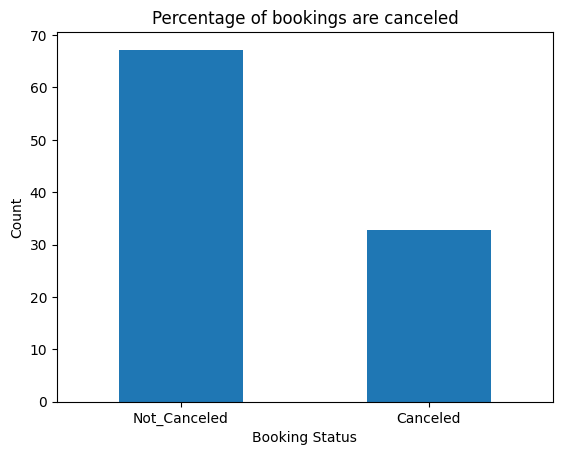

In [103]:
d.plot(kind='bar')
plt.title('Percentage of bookings are canceled')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.xticks(rotation=360)
plt.show()

#### **5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?**

In [105]:
e = data.loc[data['booking_status'] == 'Canceled', 'repeated_guest'].value_counts(normalize= True)*100
print(e)

repeated_guest
0    99.865377
1     0.134623
Name: proportion, dtype: float64


**Observation:** 
- Only 0.13% of cancellations are by repeating guests
- 99.87% of cancellations are by non-repeating guests

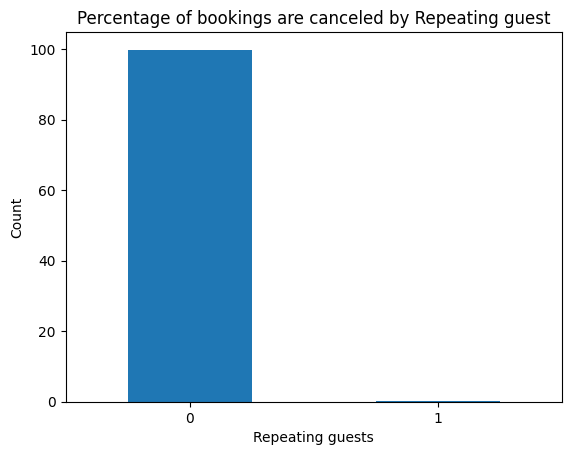

In [107]:
e.plot(kind='bar')
plt.title('Percentage of bookings are canceled by Repeating guest')
plt.xlabel('Repeating guests')
plt.ylabel('Count')
plt.xticks(rotation=360)
plt.show()

#### **6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?**

In [109]:
f = data.groupby(['no_of_special_requests'])[['booking_status']].value_counts(normalize= True)*100
fi = pd.DataFrame(f)
fi

proportion
no_of_special_requests booking_status            
0                      Not_Canceled     56.793245
                       Canceled         43.206755
1                      Not_Canceled     76.233184
                       Canceled         23.766816
2                      Not_Canceled     85.403300
                       Canceled         14.596700
3                      Not_Canceled    100.000000
4                      Not_Canceled    100.000000
5                      Not_Canceled    100.000000

**Observation**: Guests who make special requests:
- Only 24% for 1 request.
- Only 15% for 2 requests.
- 0% for 3 or more.
  
**Insight**: Guests with no special requests cancel more often — around 43% of these bookings are canceled.
            As the number of special requests increases, the cancellation rate drops significantly.

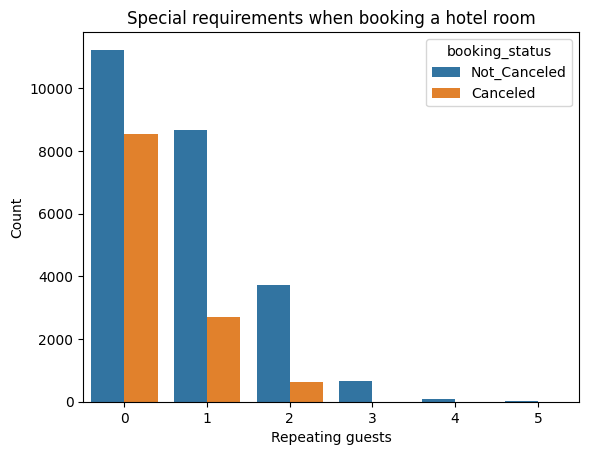

In [111]:
sns.countplot(data=data, x= 'no_of_special_requests', hue='booking_status')
plt.title('Special requirements when booking a hotel room')
plt.xlabel('Repeating guests')
plt.ylabel('Count')
plt.show()

# <a name=link1>Data Pre-Processing</a>

## Checking Missing Values

In [114]:
data.isnull().sum()

no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

There are no Missing values in the dataset.

## Outlier Detection

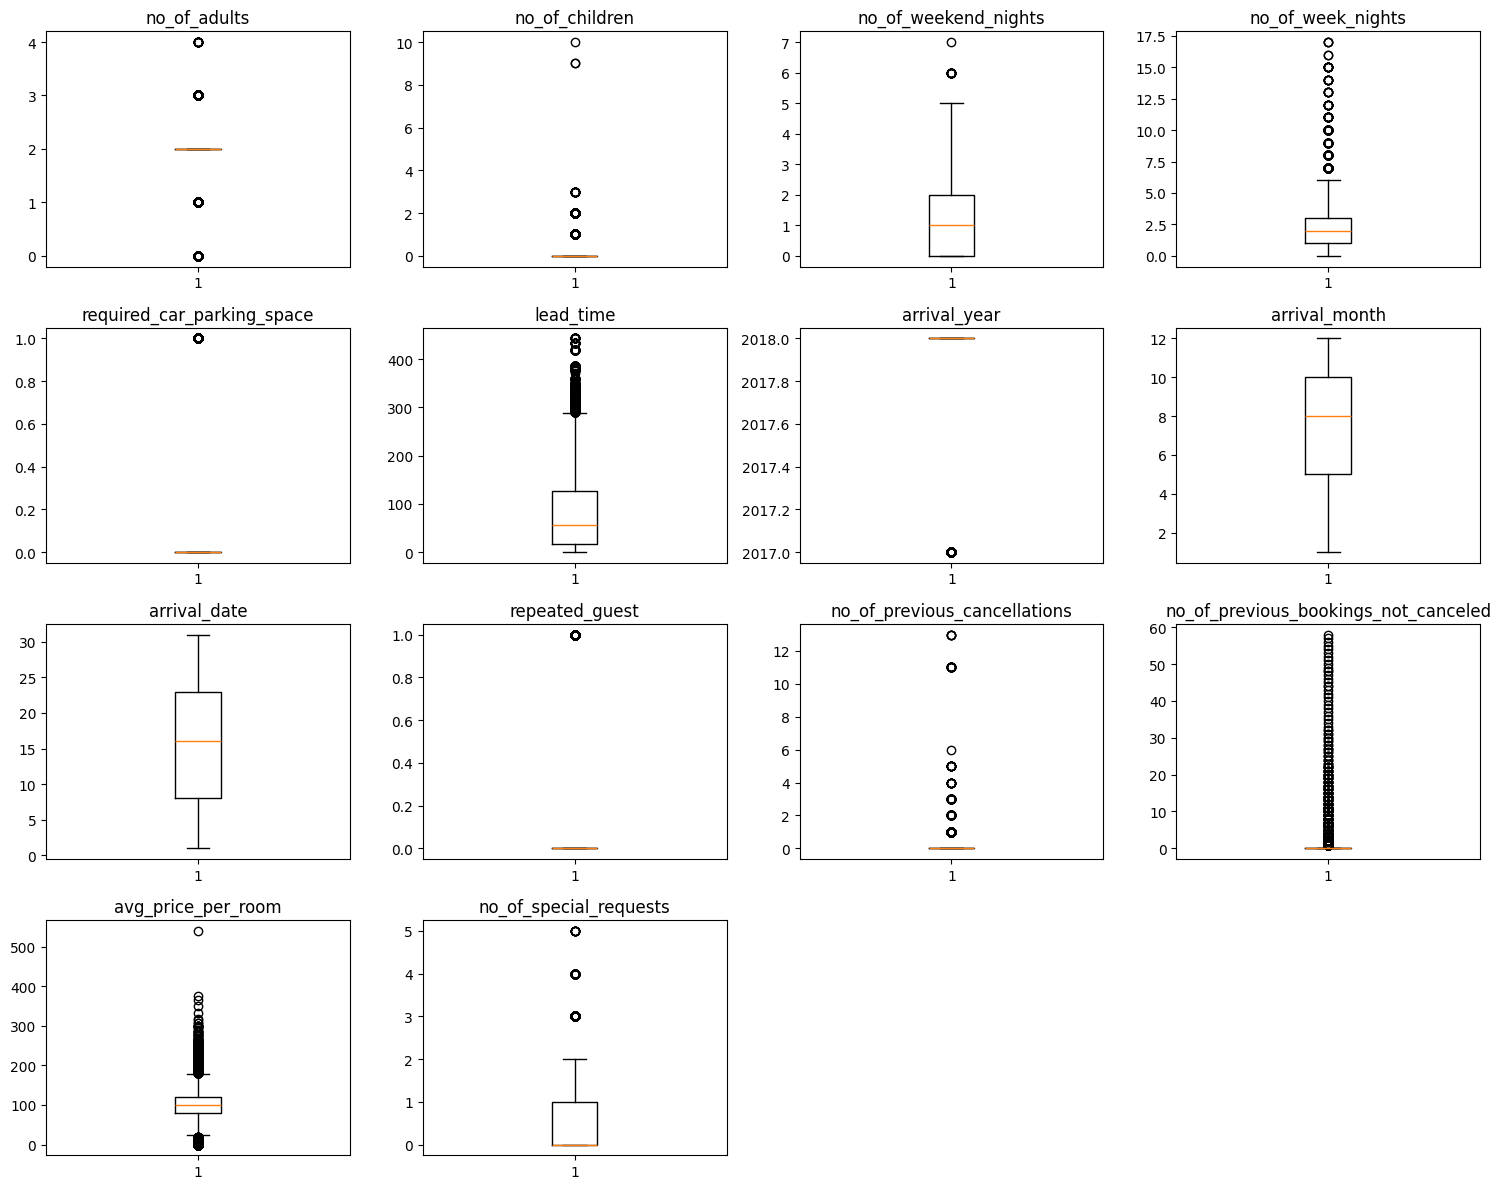

In [117]:
plt.figure(figsize=[15,12])
features = data.select_dtypes(include=['number']).columns.to_list()

for i, feature in enumerate(features):
    plt.subplot(4, 4, i+1)
    plt.boxplot(data[feature] ,whis= 1.5)
    plt.title(feature)
    plt.tight_layout()
    
plt.show()

## Treating Outliers

In [119]:
def treat_outliers(data, col):
     Q1 = data[col].quantile(0.25)
     Q3 = data[col].quantile(0.75)
     IQR = Q3 - Q1
    
     low_whisker = Q1 - 1.5 * IQR
     high_whisker = Q3 + 1.5 * IQR

     data[col] = data[col].clip(lower= low_whisker, upper= high_whisker)
     return data

In [120]:
for feature in features:
    data = treat_outliers(data, feature)

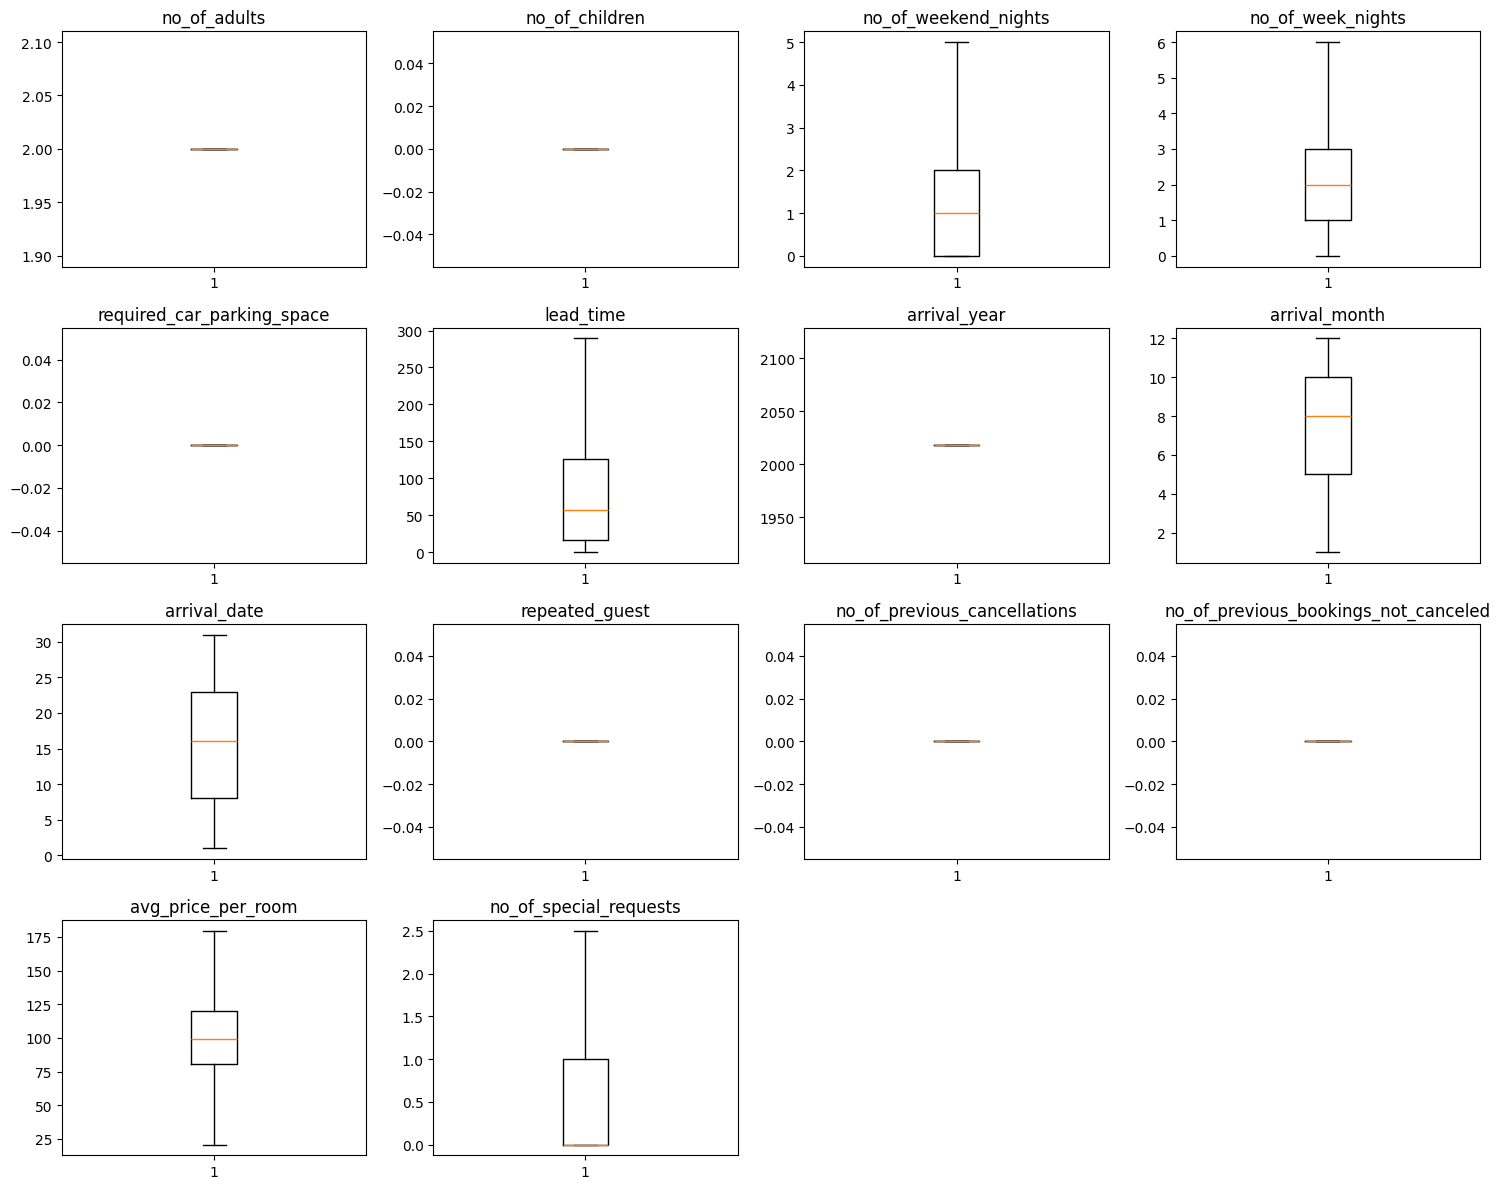

In [121]:
plt.figure(figsize=[15,12])
features = data.select_dtypes(include=['number']).columns.to_list()

for i, feature in enumerate(features):
    plt.subplot(4, 4, i+1)
    plt.boxplot(data[feature] ,whis= 1.5)
    plt.title(feature)
    plt.tight_layout()
    
plt.show()

- The outliers has been treated

## Feature Engineering

In [124]:
data['total_guests'] = data['no_of_adults'] + data['no_of_children']
data['total_nights'] = data['no_of_weekend_nights'] + data['no_of_week_nights']
data['average_price_per_night'] = data['avg_price_per_room'] / (data['total_nights'].replace(0,1))
data['is_repeated_guest'] = (data['no_of_previous_cancellations'] > 0).astype(int)
data['special_request_count'] = data['no_of_special_requests']
data['is_long_stay'] = (data['total_nights'] > 7).astype(int)
data['is_family_trip'] = (data['no_of_children'] > 0).astype(int)
data['weekend_stay'] = (data['no_of_weekend_nights'] > 0).astype(int)

# Drop columns after feature engineering
data = data.drop(columns=[
    'no_of_adults',
    'no_of_children',
    'no_of_weekend_nights',
    'no_of_week_nights',
    'avg_price_per_room',
    'no_of_previous_cancellations',
    'no_of_special_requests'
])

## Data preparation for Modeling

**Label encoding the Target variable**

In [127]:
data['booking_status'] = data['booking_status'].apply(lambda x: 1 if x =='Canceled' else 0)

In [128]:
X = data.drop(['booking_status'], axis= 1)
y = data['booking_status']

# creating dummy variables

X = pd.get_dummies(
    X,
    columns= X.select_dtypes(include=['object', 'category']).columns.to_list(),
    drop_first= True
)
X = X.astype(float)

X = X.loc[:, X.nunique() > 1]
X = X.loc[:, ~X.T.duplicated()]

# X = sm.add_constant(X)

### Train Test Split

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.30,
    random_state= 42
)

In [131]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print()
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print()
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (25392, 21)
Shape of test set :  (10883, 21)

Percentage of classes in training set:
booking_status
0    0.673992
1    0.326008
Name: proportion, dtype: float64

Percentage of classes in test set:
booking_status
0    0.668566
1    0.331434
Name: proportion, dtype: float64


In [132]:
sc = StandardScaler()

X_train_scaled = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(sc.transform(X_test), columns=X_test.columns, index=X_test.index)

In [133]:
# Adding constant to data for Logistic Regression
X_train_intercept = sm.add_constant(X_train_scaled)
X_test_intercept = sm.add_constant(X_test_scaled)

# <a name=link2>Model Building</a>

## Logistic Regression (Stats Model)

In [136]:
logistic_model = sm.Logit(y_train, X_train_intercept)

log_reg = logistic_model.fit()

         Current function value: 0.444754
         Iterations: 35


C:\Users\91824\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [137]:
print(log_reg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25370
Method:                           MLE   Df Model:                           21
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2955
Time:                        12:28:01   Log-Likelihood:                -11293.
converged:                      False   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -1.4773    534.208     -0.003      0.998   -1048.506    1045.552
lead_time                             1.3099      0.021     63

### Model Performance

In [139]:
pred_class = log_reg.predict(X_train_intercept)
pred = (pred_class > 0.5).astype(int)

In [140]:
def model_performance_logit_stats(model ,predictors, target):
    pred_class = model.predict(predictors)
    pred = (pred_class >= 0.5).astype(int)

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    df_perf = pd.DataFrame({
        "Accuracy": acc, 
        "Recall": recall, 
        "Precision": precision, 
        "F1": f1
    }, index=[0])

    return df_perf

In [141]:
def confusion_matrix_stats(model,predictors, target):

    
    pred_class = model.predict(predictors)
    pred = (pred_class > 0.5).astype(int)
    
    cm = confusion_matrix(target, pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="g", cmap= 'Spectral')
    plt.xlabel("Predicted Values")
    plt.ylabel("Actual Values")
    plt.show()

#### **Confusion Matrix**

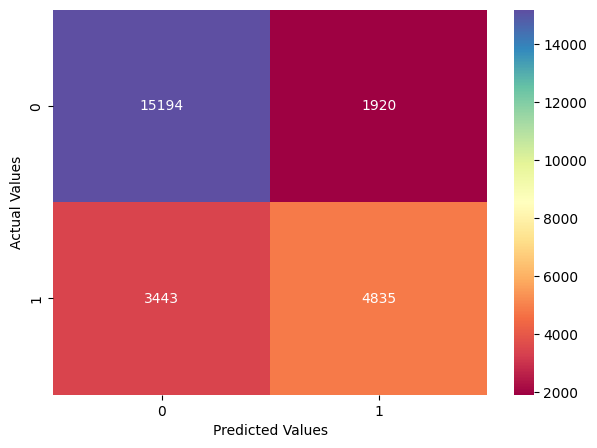

In [143]:
confusion_matrix_stats(log_reg,X_train_intercept, y_train)

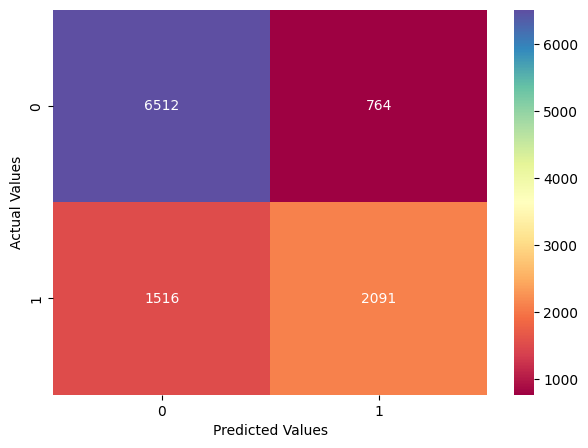

In [144]:
confusion_matrix_stats(log_reg, X_test_intercept, y_test)

#### **The confusion matrix**

* True Positives (TP):  A person has Cancelled and the model predicted person has Cancelled the booking.
* True Negatives (TN): A person doesn't have Cancelled and the model predicted person doesn't have Cancelled the booking.
* False Positives (FP): The model predicted person has Cancelled but the person doesn't have Cancelled the booking.
* False Negatives (FN): The model predicted person doesn't have Cancelled but the person has Cancelled the booking.

In [146]:
lg1_perf_train = model_performance_logit_stats(log_reg ,X_train_intercept, y_train)
lg1_perf_train

,Accuracy,Recall,Precision,F1
0,0.788792,0.584078,0.715766,0.643252


AUC: 0.74


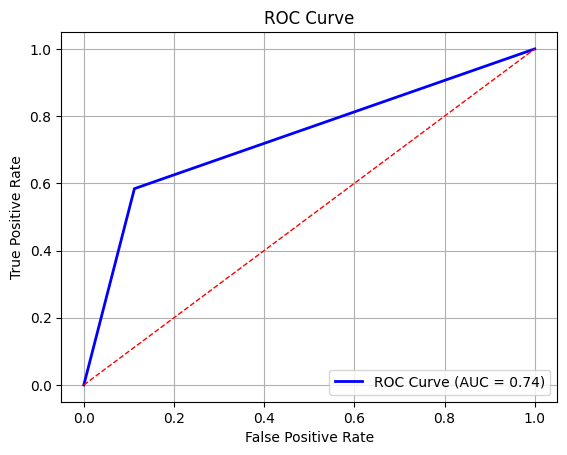

In [147]:
pred_class = log_reg.predict(X_train_intercept)
pred = (pred_class > 0.5).astype(int)
fpr, tpr, threshold = roc_curve(y_train, pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [148]:
lg1_perf_test = model_performance_logit_stats(log_reg ,X_test_intercept, y_test)
lg1_perf_test

,Accuracy,Recall,Precision,F1
0,0.790499,0.579706,0.732399,0.647168


AUC: 0.74


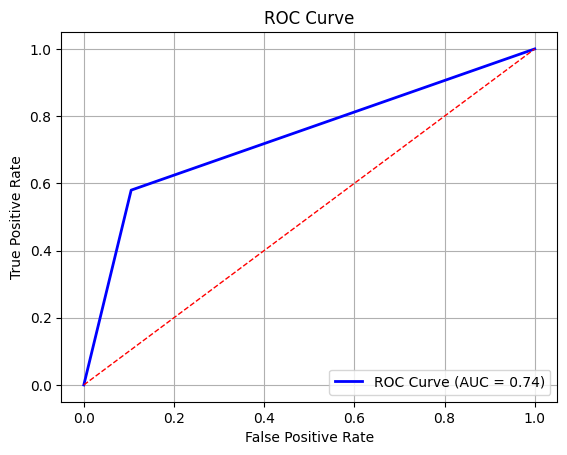

In [149]:
pred_class = log_reg.predict(X_test_intercept)
pred = (pred_class > 0.5).astype(int)
fpr, tpr, threshold = roc_curve(y_test, pred)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")


plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Decision Tree Classifier (sklearn)

In [151]:
D_model1 = DecisionTreeClassifier(random_state= 42)

D_model1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Model Performance

In [153]:
D_model1.score(X_test, y_test)

0.8609758338693375

In [154]:
def model_performance_DecisionTree_sklearn(model, predictors, target):
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  
    recall = recall_score(target, pred) 
    precision = precision_score(target, pred) 
    f1 = f1_score(target, pred) 

    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [155]:
def confusion_matrix_Decision_sklearn(model, predictors, target):
    
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="", cmap= 'Spectral')
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

**Train**

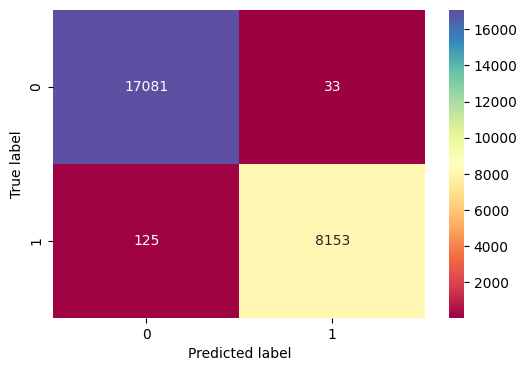

In [157]:
confusion_matrix_Decision_sklearn(D_model1, X_train, y_train)

In [158]:
decision_tree_default_perf_train = model_performance_DecisionTree_sklearn(D_model1, X_train, y_train)
decision_tree_default_perf_train

,Accuracy,Recall,Precision,F1
0,0.993778,0.9849,0.995969,0.990403


**Test**

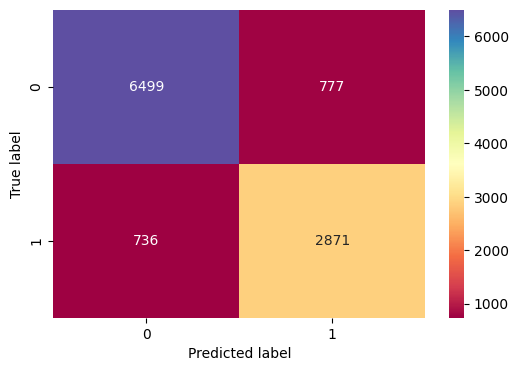

In [160]:
confusion_matrix_Decision_sklearn(D_model1, X_test, y_test)

In [161]:
decision_tree_default_perf_test = model_performance_DecisionTree_sklearn(D_model1, X_test, y_test)
decision_tree_default_perf_test

,Accuracy,Recall,Precision,F1
0,0.860976,0.795952,0.787007,0.791454


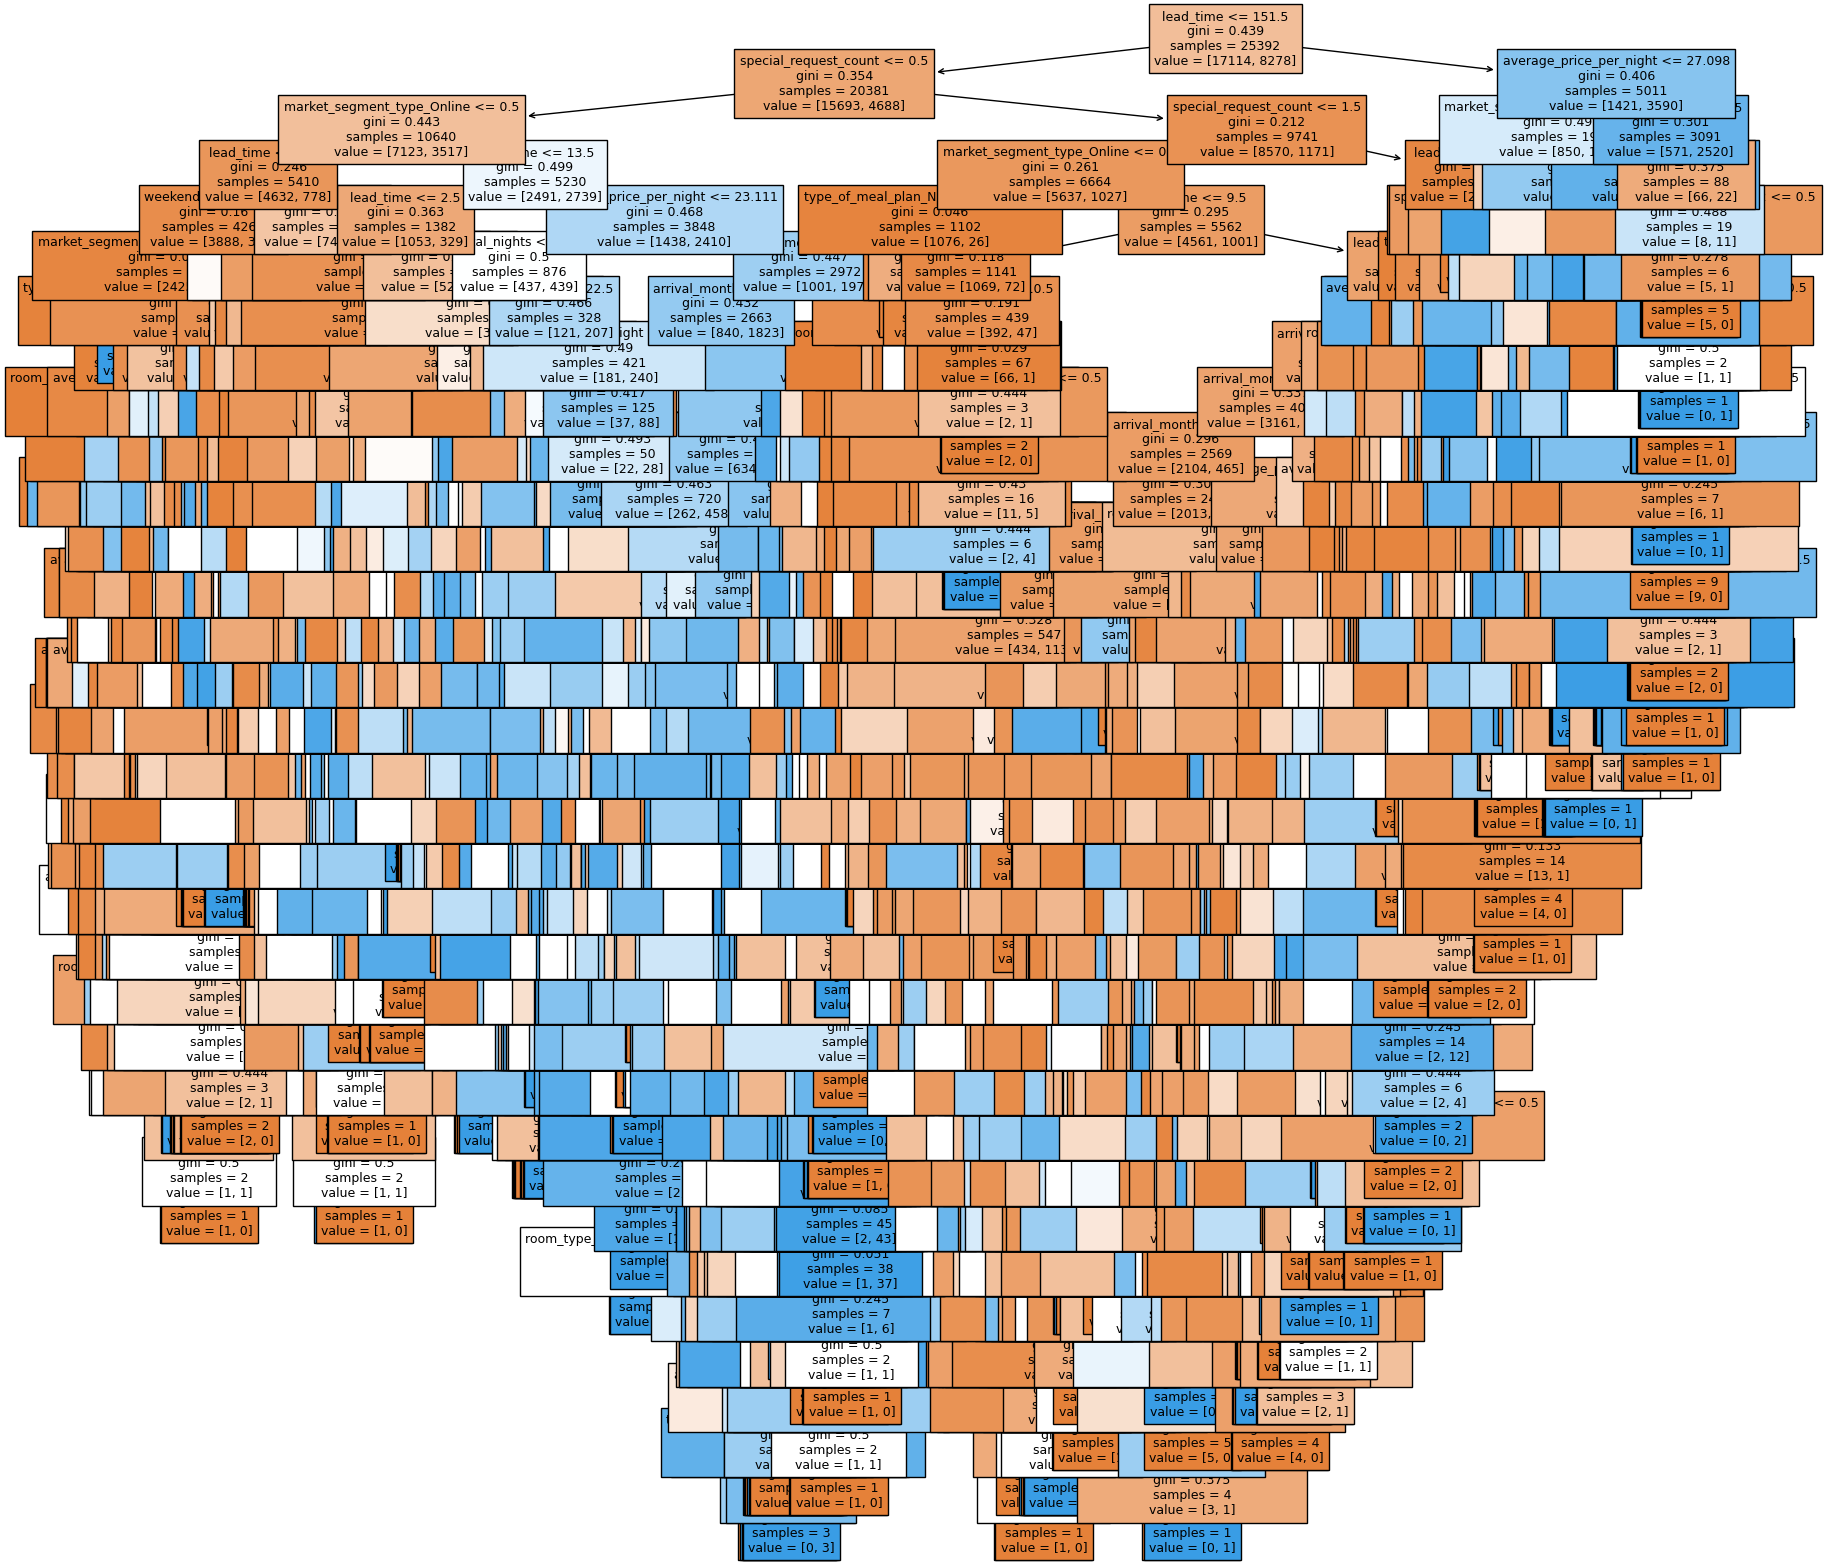

In [162]:
feature_names = list(X_train.columns)

plt.figure(figsize=(20, 20))

out = tree.plot_tree(
    D_model1,
    feature_names=feature_names,   
    filled=True,                    
    fontsize=9,                    
    node_ids=False,                 
    class_names=None,              
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    
        arrow.set_linewidth(1)         

plt.show()

In [163]:
feature_names = list(X_train.columns)
print(
    tree.export_text(
        D_model1,
        feature_names=feature_names,    
        show_weights=True  
    )
)

|--- lead_time <= 151.50
|   |--- special_request_count <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 92.50
|   |   |   |   |--- weekend_stay <= 0.50
|   |   |   |   |   |--- market_segment_type_Corporate <= 0.50
|   |   |   |   |   |   |--- type_of_meal_plan_Meal Plan 3 <= 0.50
|   |   |   |   |   |   |   |--- arrival_date <= 22.50
|   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 <= 0.50
|   |   |   |   |   |   |   |   |   |--- weights: [1349.00, 0.00] class: 0
|   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 >  0.50
|   |   |   |   |   |   |   |   |   |--- lead_time <= 89.50
|   |   |   |   |   |   |   |   |   |   |--- market_segment_type_Offline <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |   |--- market_segment_type_Offline >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [78.00, 0.00] class: 0
|   |   |   |   | 

## Model performance across different metrics

### Training performance comparison

In [166]:
models_train_comp_df = pd.concat(
    [
        lg1_perf_train.T,
        decision_tree_default_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Model Default (Stats)",
    "Decision Tree default (sklearn)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Model Default (Stats),Decision Tree default (sklearn)
Accuracy,0.788792,0.993778
Recall,0.584078,0.984900
Precision,0.715766,0.995969
F1,0.643252,0.990403


### Insights (Training)

**Logistic Model (Stats):**

- Shows decent performance.

- Recall = 58.40%

- It is not perfect, but not overfitting.

**Decision Tree (Sklearn):**

- Near-perfect scores.

- Classic sign of overfitting.

### Test performance comparison

In [169]:
models_test_comp_df = pd.concat(
    [        
        lg1_perf_test.T,
        decision_tree_default_perf_test.T,
        
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Model Default (Stats)",
    "Decision Tree (sklearn default)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Logistic Model Default (Stats),Decision Tree (sklearn default)
Accuracy,0.790499,0.860976
Recall,0.579706,0.795952
Precision,0.732399,0.787007
F1,0.647168,0.791454


### Insights (Test)

**Logistic Model (Stats):**

- Performance is stable from training to test.

- No sign of overfitting.

- It needs preprocessing or balancing.

**Decision Tree (Sklearn):**

- The drop in metrics from training to test is huge and confirms overfitting, but it's still the better-performing model.


### **Final Observations:**

- Logistic regression is not good without addressing imbalance or threshold tuning.

- Decision Tree requires regularization (pre-/post-pruning) to improve generalization.

# <a name=link3>Model Performance Improvement</a>

## Logistic Regression (Stats Model)

### Checking for Multicollinearity

In [175]:
vif_series = pd.Series(
    [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])],
    index=X_train_scaled.columns,
    dtype=float,
)

print("VIF values:\n\n{}\n".format(vif_series))


VIF values:

lead_time                             1.238603
arrival_month                         1.044660
arrival_date                          1.005782
total_nights                          3.462733
average_price_per_night               2.611296
special_request_count                 1.218679
is_long_stay                          1.423952
weekend_stay                          1.308326
type_of_meal_plan_Meal Plan 2         1.141377
type_of_meal_plan_Meal Plan 3         1.006281
type_of_meal_plan_Not Selected        1.214495
room_type_reserved_Room_Type 2        1.028952
room_type_reserved_Room_Type 3        1.004402
room_type_reserved_Room_Type 4        1.199634
room_type_reserved_Room_Type 5        1.024869
room_type_reserved_Room_Type 6        1.088547
room_type_reserved_Room_Type 7        1.039743
market_segment_type_Complementary     4.334972
market_segment_type_Corporate        17.012141
market_segment_type_Offline          63.581376
market_segment_type_Online           70.419815


**Variables with High Multicollinearity:**
- market_segment_type_Corporate: VIF = 17
- market_segment_type_Offline: VIF = 63.58
- market_segment_type_Online: VIF = 70.41

 **So, we Drop the columns**

#### Dropping the columns which has Multicollinearity

In [178]:
Columns_to_remove = ['market_segment_type_Corporate', 'market_segment_type_Offline', 'market_segment_type_Online']
X_train_intercept = X_train_intercept.drop(columns= Columns_to_remove)

#### After dropping high multicollinearity features

In [180]:
vif_series_after_removal = pd.Series(
    [variance_inflation_factor(X_train_intercept.values, i) for i in range(X_train_intercept.shape[1])],
    index=X_train_intercept.columns,
    dtype=float
)

print("VIF values after removing high multicollinearity features: \n\n{}\n".format(vif_series_after_removal))

VIF values after removing high multicollinearity features: 

const                                1.000000
lead_time                            1.172380
arrival_month                        1.040715
arrival_date                         1.005581
total_nights                         3.312924
average_price_per_night              2.497920
special_request_count                1.078661
is_long_stay                         1.408888
weekend_stay                         1.304627
type_of_meal_plan_Meal Plan 2        1.086953
type_of_meal_plan_Meal Plan 3        1.006141
type_of_meal_plan_Not Selected       1.093550
room_type_reserved_Room_Type 2       1.016156
room_type_reserved_Room_Type 3       1.004223
room_type_reserved_Room_Type 4       1.150332
room_type_reserved_Room_Type 5       1.016356
room_type_reserved_Room_Type 6       1.078364
room_type_reserved_Room_Type 7       1.039292
market_segment_type_Complementary    1.136131
dtype: float64



### Removing insignificant variables (p-value > 0.05)

In [182]:
print(log_reg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25370
Method:                           MLE   Df Model:                           21
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2955
Time:                        12:35:20   Log-Likelihood:                -11293.
converged:                      False   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -1.4773    534.208     -0.003      0.998   -1048.506    1045.552
lead_time                             1.3099      0.021     63

**market_segment_type_Complementary as it has the highest p-value**

In [184]:
X_train1_intercept = X_train_intercept.drop("market_segment_type_Complementary", axis=1)

In [185]:
logistic_model1 = sm.Logit(y_train, X_train1_intercept)

log_reg1 = logistic_model1.fit()

y_pred_train1 = log_reg1.predict(X_train1_intercept)
y_pred_train1 = np.round(y_pred_train1)

print("Accuracy on training set : ", accuracy_score(y_train, y_pred_train1))

Optimization terminated successfully.
         Current function value: 0.482123
         Iterations 6
Accuracy on training set :  0.7636263390044108


In [186]:
print(log_reg1.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25374
Method:                           MLE   Df Model:                           17
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2363
Time:                        12:35:20   Log-Likelihood:                -12242.
converged:                       True   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.9728      0.017    -57.304      0.000      -1.006      -0.940
lead_time                          1.1447      0.018     62.059      0.

**room_type_reserved_Room_Type 3 as it has the highest p-value**

In [188]:
X_train2_intercept = X_train1_intercept.drop("room_type_reserved_Room_Type 3", axis=1)

In [189]:
logistic_model2 = sm.Logit(y_train, X_train2_intercept.astype(float))

log_reg2 = logistic_model2.fit()

y_pred_train2 = log_reg2.predict(X_train2_intercept)
y_pred_train2 = np.round(y_pred_train2)

print("Accuracy on training set : ", accuracy_score(y_train, y_pred_train2))

Optimization terminated successfully.
         Current function value: 0.482126
         Iterations 6
Accuracy on training set :  0.7635475740390675


In [190]:
print(log_reg2.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25375
Method:                           MLE   Df Model:                           16
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2363
Time:                        12:35:21   Log-Likelihood:                -12242.
converged:                       True   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.9728      0.017    -57.304      0.000      -1.006      -0.940
lead_time                          1.1446      0.018     62.058      0.

**room_type_reserved_Room_Type 2 as it has the highest p-value**

In [192]:
X_train3_intercept = X_train2_intercept.drop("room_type_reserved_Room_Type 2", axis=1)

In [193]:
logistic_model3 = sm.Logit(y_train, X_train3_intercept.astype(float))

log_reg3 = logistic_model3.fit()

y_pred_train3 = log_reg3.predict(X_train3_intercept)
y_pred_train3 = np.round(y_pred_train3)

print("Accuracy on training set : ", accuracy_score(y_train, y_pred_train3))

Optimization terminated successfully.
         Current function value: 0.482133
         Iterations 6
Accuracy on training set :  0.763193131695022


In [194]:
print(log_reg3.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25376
Method:                           MLE   Df Model:                           15
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2363
Time:                        12:35:21   Log-Likelihood:                -12242.
converged:                       True   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.9727      0.017    -57.305      0.000      -1.006      -0.939
lead_time                          1.1450      0.018     62.101      0.

**type_of_meal_plan_Meal Plan 3 as it has the highest p-value**

In [196]:
X_train4_intercept = X_train3_intercept.drop("type_of_meal_plan_Meal Plan 3", axis=1)

In [197]:
logistic_model4 = sm.Logit(y_train, X_train4_intercept.astype(float))

log_reg4 = logistic_model4.fit()

y_pred_train4 = log_reg4.predict(X_train4_intercept)
y_pred_train4 = np.round(y_pred_train4)

print("Accuracy on training set : ", accuracy_score(y_train, y_pred_train4))

Optimization terminated successfully.
         Current function value: 0.482142
         Iterations 6
Accuracy on training set :  0.7631537492123504


In [198]:
print(log_reg4.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25377
Method:                           MLE   Df Model:                           14
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2363
Time:                        12:35:22   Log-Likelihood:                -12243.
converged:                       True   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.9727      0.017    -57.305      0.000      -1.006      -0.939
lead_time                          1.1449      0.018     62.099      0.

**type_of_meal_plan_Meal Plan 2 as it has the highest p-value**

In [200]:
X_train5_intercept = X_train4_intercept.drop("type_of_meal_plan_Meal Plan 2", axis=1)

In [201]:
logistic_model5 = sm.Logit(y_train, X_train5_intercept.astype(float))

log_reg5 = logistic_model5.fit()

y_pred_train5 = log_reg5.predict(X_train5_intercept)
y_pred_train5 = np.round(y_pred_train5)

print("Accuracy on training set : ", accuracy_score(y_train, y_pred_train5))

Optimization terminated successfully.
         Current function value: 0.482163
         Iterations 6
Accuracy on training set :  0.763468809073724


In [202]:
print(log_reg5.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25378
Method:                           MLE   Df Model:                           13
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2363
Time:                        12:35:22   Log-Likelihood:                -12243.
converged:                       True   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.9728      0.017    -57.307      0.000      -1.006      -0.940
lead_time                          1.1417      0.018     62.828      0.

**is_long_stay as it has the highest p-value**

In [204]:
X_train6_intercept = X_train5_intercept.drop("is_long_stay", axis=1)

In [205]:
logistic_model6 = sm.Logit(y_train, X_train6_intercept.astype(float))

log_reg6 = logistic_model6.fit()

y_pred_train6 = log_reg6.predict(X_train6_intercept)
y_pred_train6 = np.round(y_pred_train6)

print("Accuracy on training set : ", accuracy_score(y_train, y_pred_train6))

Optimization terminated successfully.
         Current function value: 0.482194
         Iterations 6
Accuracy on training set :  0.764689666036547


In [206]:
print(log_reg6.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25379
Method:                           MLE   Df Model:                           12
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2362
Time:                        12:35:23   Log-Likelihood:                -12244.
converged:                       True   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.9722      0.017    -57.308      0.000      -1.005      -0.939
lead_time                          1.1423      0.018     62.864      0.

**room_type_reserved_Room_Type 5 as it has the highest p-value**

In [208]:
X_train7_intercept = X_train6_intercept.drop("room_type_reserved_Room_Type 5", axis=1)

In [209]:
logistic_model7 = sm.Logit(y_train, X_train7_intercept.astype(float))

log_reg7 = logistic_model7.fit()

y_pred_train7 = log_reg7.predict(X_train7_intercept)
y_pred_train7 = np.round(y_pred_train6)

print("Accuracy on training set : ", accuracy_score(y_train, y_pred_train7))

Optimization terminated successfully.
         Current function value: 0.482225
         Iterations 6
Accuracy on training set :  0.764689666036547


In [210]:
print(log_reg7.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25380
Method:                           MLE   Df Model:                           11
Date:                Sun, 27 Apr 2025   Pseudo R-squ.:                  0.2362
Time:                        12:35:23   Log-Likelihood:                -12245.
converged:                       True   LL-Null:                       -16030.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -0.9720      0.017    -57.304      0.000      -1.005      -0.939
lead_time                          1.1428      0.018     62.907      0.

### Performance Metrics of the final model

In [212]:
X_train_final = X_train7_intercept.copy()
X_test_final = X_test_intercept[X_train_final.columns]

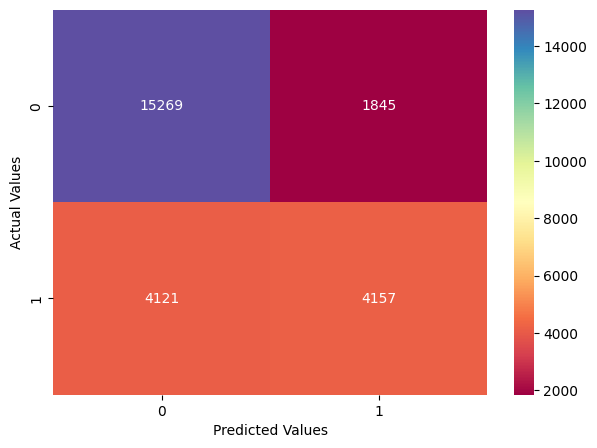

In [213]:
confusion_matrix_stats(log_reg7, X_train_final, y_train)

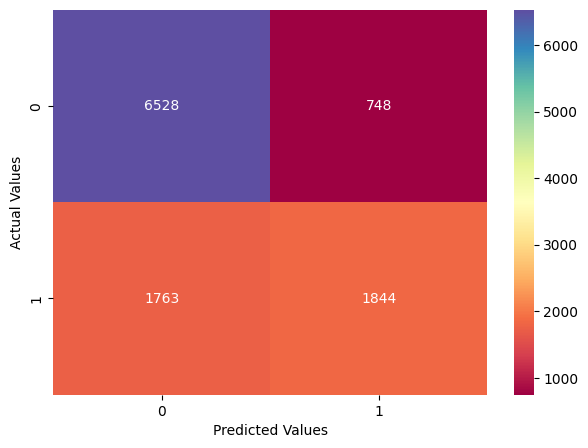

In [214]:
confusion_matrix_stats(log_reg7, X_test_final, y_test)

### Roc-Auc Curve (Train)

In [216]:
y_pred_log7 = log_reg7.predict(X_train_final)

In [217]:
fpr, tpr, thresholds = roc_curve(y_train, y_pred_log7)

In [218]:
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.2f}")

AUC: 0.82


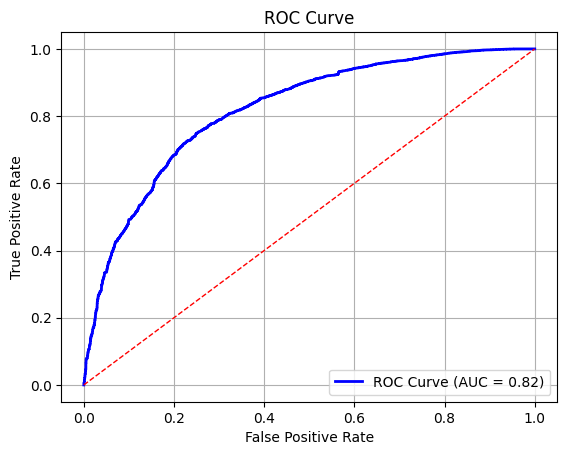

In [219]:
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Roc-Auc Curve (Test)

AUC: 0.83


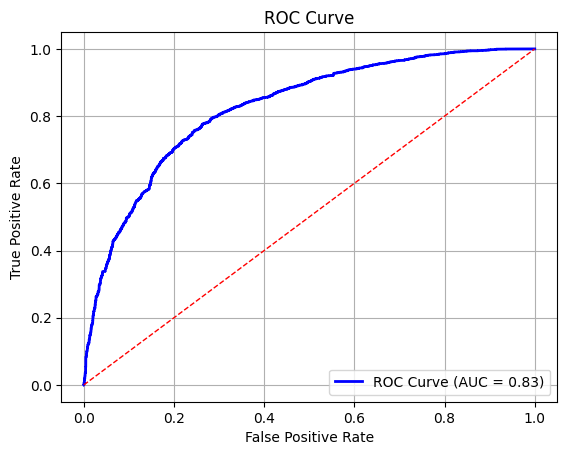

In [221]:
y_pred_log7 = log_reg7.predict(X_test_final) 

fpr, tpr, threshold = roc_curve(y_test, y_pred_log7) 
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.2f}")

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--') 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


### Optimal Threshold

In [223]:
y_pred_log7 = log_reg7.predict(X_test_final)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_log7)

j_scores = tpr - fpr
optimal_idx = j_scores.argmax()
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.2f}")

Optimal Threshold: 0.29


### Train

In [225]:
y_pred_probs = log_reg7.predict(X_train_final)

# Calculate performance using threshold 0.29
y_pred_final = (y_pred_probs > 0.29).astype(int)
lg1_perf_train1 = model_performance_logit_stats(log_reg7, X_train_final, y_pred_final)
lg1_perf_train1

,Accuracy,Recall,Precision,F1
0,0.793321,0.533511,1.0,0.695803


### Test

In [227]:
y_pred_probs = log_reg7.predict(X_test_final)

# Calculate performance using threshold 0.32
y_pred_final = (y_pred_probs > 0.32).astype(int)
lg1_perf_test1 = model_performance_logit_stats(log_reg7, X_test_final, y_pred_final)
lg1_perf_test1


,Accuracy,Recall,Precision,F1
0,0.834696,0.590298,1.0,0.742374


### Training Comparison of Logistic Regression (Stats)

In [229]:
models_train_comp_df = pd.concat(
    [
        lg1_perf_train.T,
        lg1_perf_train1.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Model Default (Stats)",
    "Logistic Model Threshold of 0.29",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Model Default (Stats),Logistic Model Threshold of 0.29
Accuracy,0.788792,0.793321
Recall,0.584078,0.533511
Precision,0.715766,1.000000
F1,0.643252,0.695803


#### **Insights (Training):**

**Logistic Model Default (Threshold = 0.5):**
- Shows decent baseline performance.
- Recall = 58.40% 
- Precision = 72%
- F1 = 64.32%  balance between recall and precision.

Not overfitting, as performance is reasonable without extreme values.

**Logistic Model with Threshold (0.29):**
- Improved performance across all metrics.
- Accuracy = 79.33% significantly better than default.
- Recall = 53.3% 
- Precision = 100% (very high confidence).
- F1 = 69.58% strong overall performance.

It has made good progress.

### Test Comparison of Logistic Regression (Stats)

In [232]:
models_train_comp_df = pd.concat(
    [
        lg1_perf_train.T,
        lg1_perf_test1.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Model Default (Stats)",
    "Logistic Model Threshold of 0.29",
]
print("Test performance comparison:")
models_train_comp_df

Test performance comparison:


,Logistic Model Default (Stats),Logistic Model Threshold of 0.29
Accuracy,0.788792,0.834696
Recall,0.584078,0.590298
Precision,0.715766,1.000000
F1,0.643252,0.742374


#### **Insights (Test):**

**Logistic Model Default (Threshold = 0.5):**
- Decent generalization from training to test set.
- Accuracy = 78.87% 
- Recall = 58.40%
- Precision = 72%
- F1 = 64.32%  balance performance.

No signs of overfitting

**Logistic Model with Threshold (0.29):**
- Better overall performance on test data.
- Accuracy = 83.46% significantly better than default.
- Recall = 59.02% 
- Precision = 100% (very high confidence).
- F1 = 74.23% strong overall performance.

It has made good progress than training set.

## Decision Tree (Sklearn)

### Model Performance

### Pre-Pruning

In [237]:
# Choose the type of classifier.
D_model2 = DecisionTreeClassifier(random_state=42)

# Grid of parameters to choose from
parameters = {
    'max_depth': [3, 5, 7, 9, 12],
    'min_samples_split': [2, 5, 10, 20],
    'max_leaf_nodes': [10, 20, 30, 50],
    "class_weight": ['balanced', None] 
}

# Run the grid search
grid_obj = GridSearchCV(D_model2, parameters, scoring='recall', cv=5,n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
D_model2 = grid_obj.best_estimator_

# Fit the best algorithm to the data.
D_model2.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=12, max_leaf_nodes=50,
                       random_state=42)

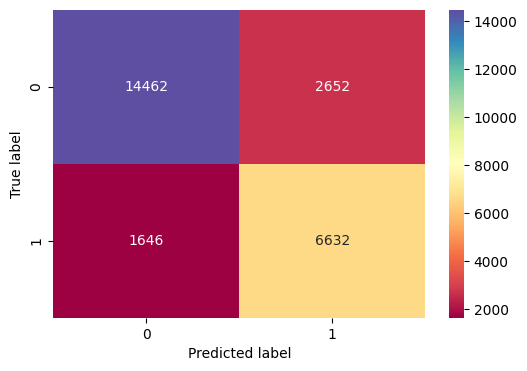

In [238]:
confusion_matrix_Decision_sklearn(D_model2, X_train, y_train)

In [239]:
decision_tree_pre_prune_perf_train = model_performance_DecisionTree_sklearn(D_model2, X_train, y_train)
decision_tree_pre_prune_perf_train

,Accuracy,Recall,Precision,F1
0,0.830734,0.80116,0.714347,0.755267


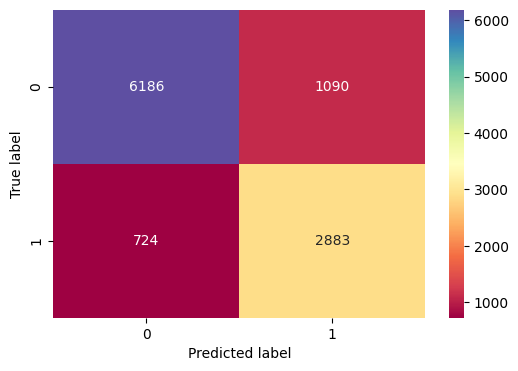

In [240]:
confusion_matrix_Decision_sklearn(D_model2, X_test, y_test)

In [241]:
decision_tree_pre_prune_perf_test = model_performance_DecisionTree_sklearn(D_model2, X_test, y_test)
decision_tree_pre_prune_perf_test

,Accuracy,Recall,Precision,F1
0,0.833318,0.799279,0.725648,0.760686


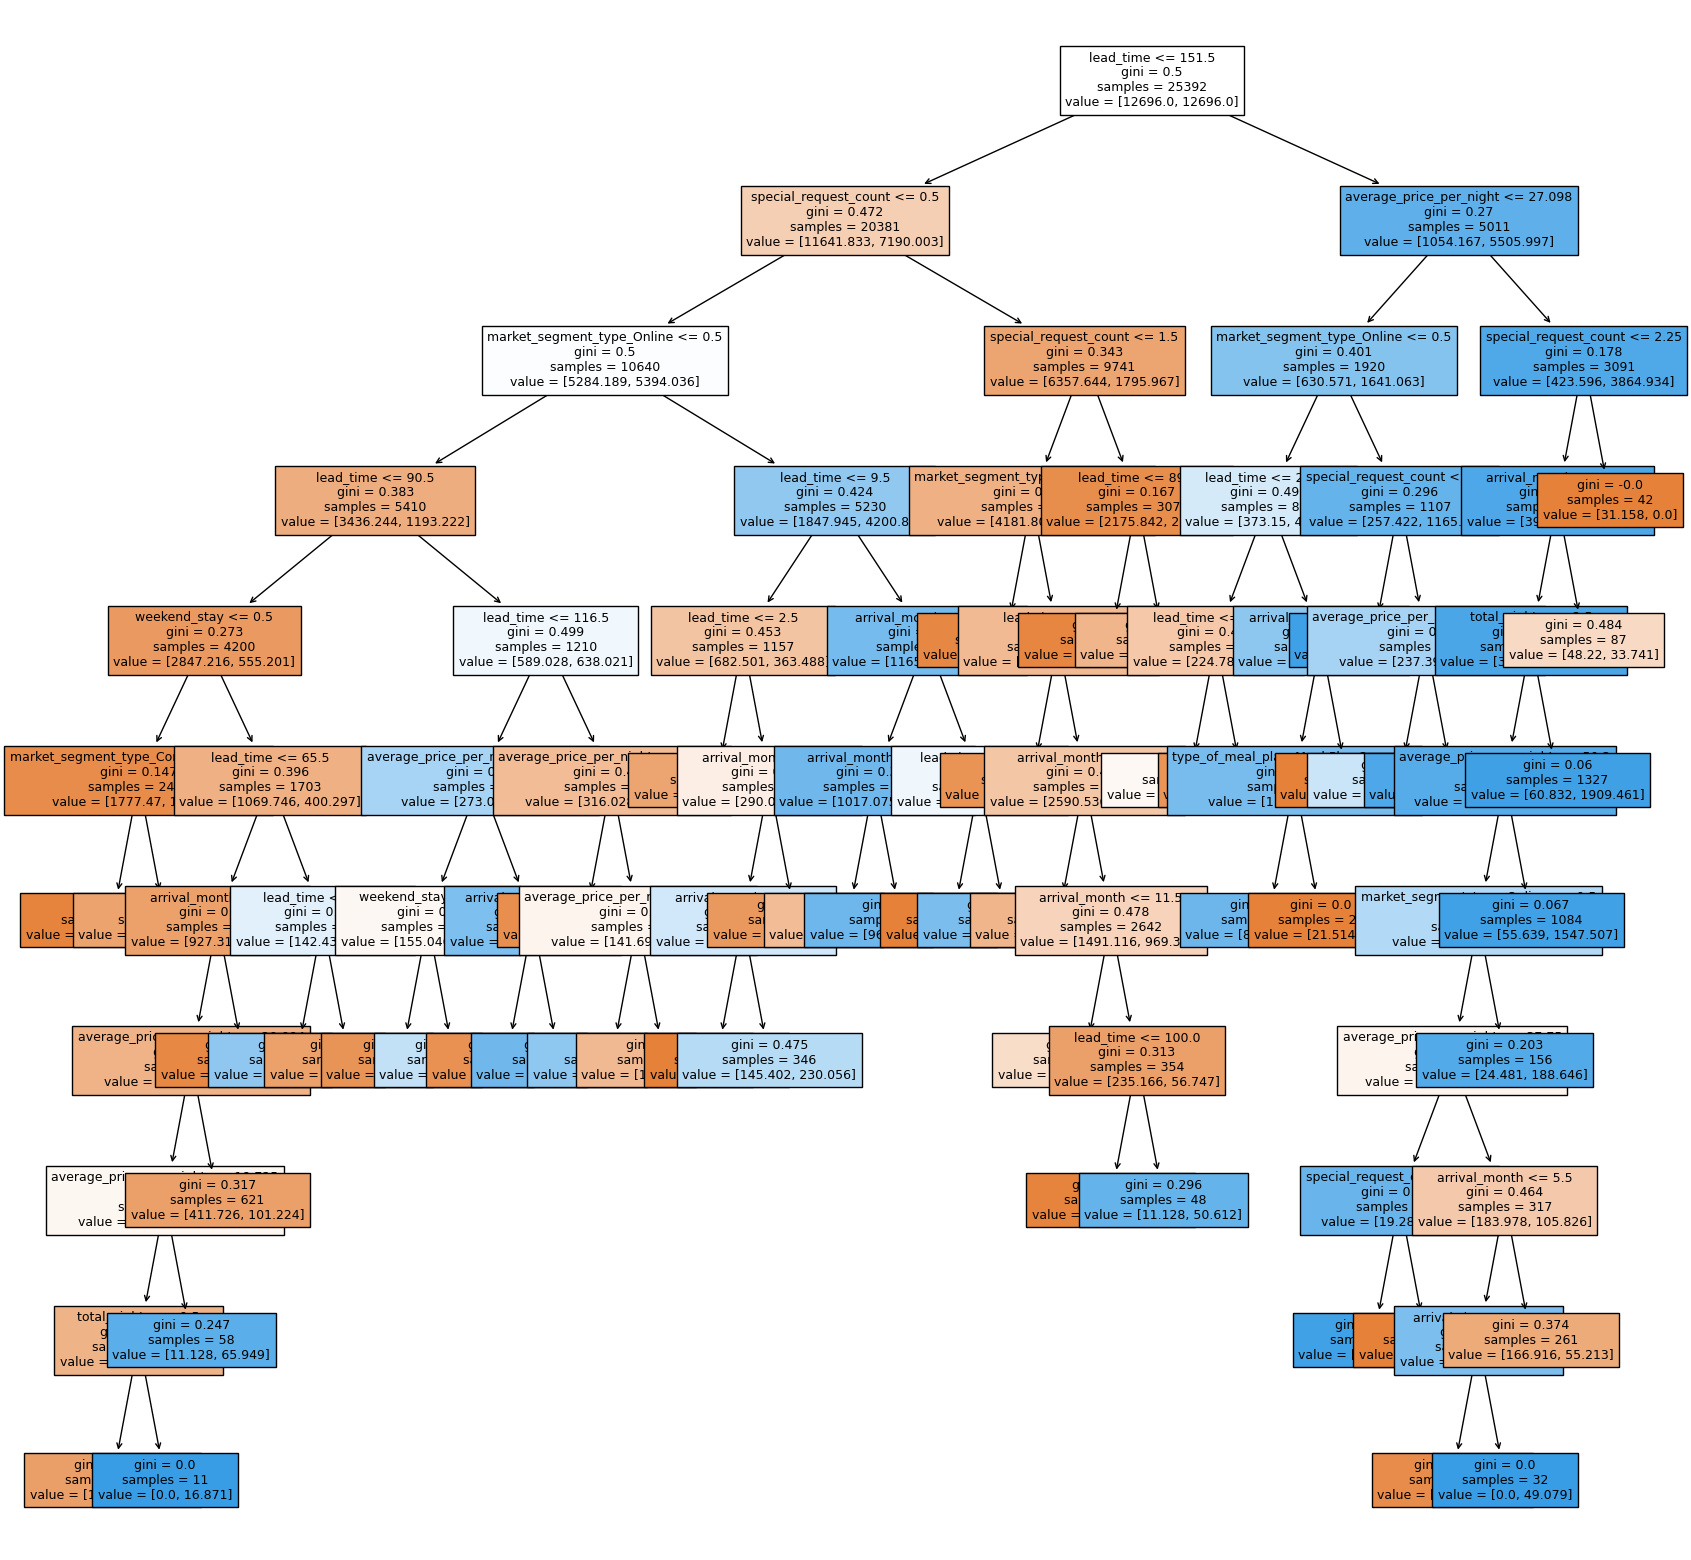

In [242]:
feature_names = list(X_train.columns)

plt.figure(figsize=(20, 20))

out = tree.plot_tree(
    D_model2,
    feature_names=feature_names,   
    filled=True,                    
    fontsize=9,                    
    node_ids=False,                 
    class_names=None,              
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    
        arrow.set_linewidth(1)         

plt.show()

In [243]:
feature_names = list(X_train.columns)
print(
    tree.export_text(
        D_model2,
        feature_names=feature_names,    
        show_weights=True  
    )
)

|--- lead_time <= 151.50
|   |--- special_request_count <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- weekend_stay <= 0.50
|   |   |   |   |   |--- market_segment_type_Corporate <= 0.50
|   |   |   |   |   |   |--- weights: [1325.68, 33.74] class: 0
|   |   |   |   |   |--- market_segment_type_Corporate >  0.50
|   |   |   |   |   |   |--- weights: [451.79, 121.16] class: 0
|   |   |   |   |--- weekend_stay >  0.50
|   |   |   |   |   |--- lead_time <= 65.50
|   |   |   |   |   |   |--- arrival_month <= 9.50
|   |   |   |   |   |   |   |--- average_price_per_night <= 20.09
|   |   |   |   |   |   |   |   |--- average_price_per_night <= 18.73
|   |   |   |   |   |   |   |   |   |--- total_nights <= 9.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [103.86, 24.54] class: 0
|   |   |   |   |   |   |   |   |   |--- total_nights >  9.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [0.00, 16.87] class: 1
|  

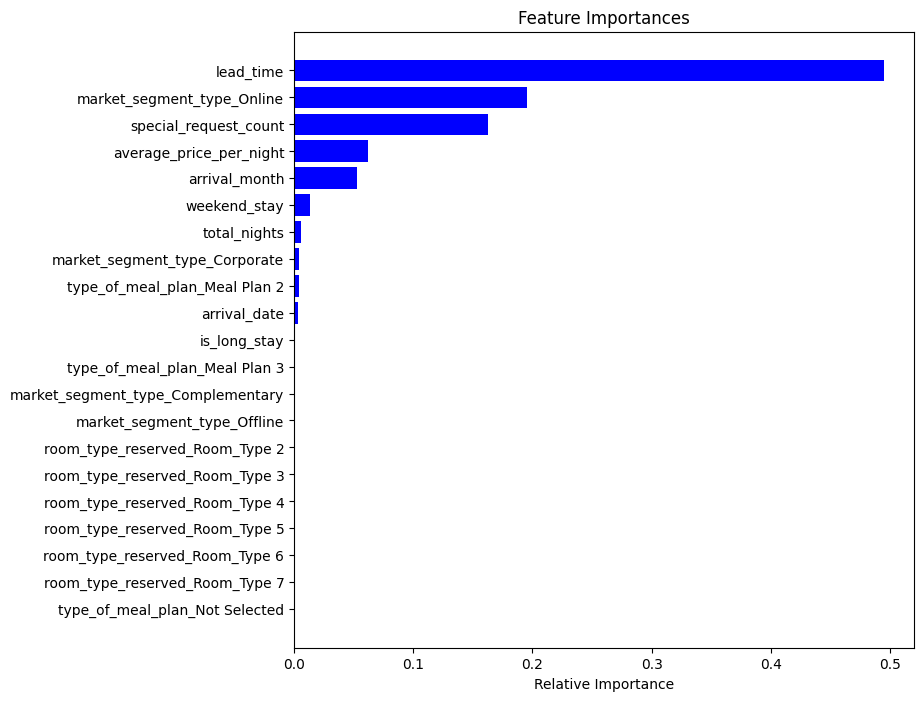

In [244]:
importances = D_model2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

1.	lead_time
           Most important by far (almost 50% relative importance).
    (Typically, bookings made far in advance have higher chances of cancellation.)

2.	market_segment_type_Online
Online bookings are the second biggest factor.
Online customers might behave differently — more flexible to cancel compared to walk-ins or corporate bookings.


3.	special_request_count
 Special requests (like extra beds, late checkouts) are important too.
 Customers who make special requests might be more serious about showing up, or very selective.

4.	average_price_per_night
Higher priced bookings impact cancellations.
Possibly, expensive stays cause more cancellations if customers change their mind.


### Post-Pruning

In [247]:
ccp_alpha_values = np.linspace(0.0, 0.05, 20)

best_estimator_recall = None
best_recall_diff = float('inf')
train_recall_scores = []
test_recall_scores = []

for ccp_alpha in ccp_alpha_values:
    estimator = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    estimator.fit(X_train, y_train)
    
    y_train_pred = estimator.predict(X_train)
    y_test_pred = estimator.predict(X_test)
    
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    
    train_recall_scores.append(train_recall)
    test_recall_scores.append(test_recall)
    
    recall_diff = abs(test_recall - train_recall)
    
    if recall_diff < best_recall_diff:
        best_recall_diff = recall_diff
        best_estimator_recall = estimator

best_ccp_alpha_recall = best_estimator_recall.ccp_alpha

print(f"Best ccp_alpha: {best_estimator_recall.ccp_alpha}")
print(f"Best Recall Score Difference: {best_recall_diff}")

Best ccp_alpha: 0.013157894736842105
Best Recall Score Difference: 0.0010412694491590546


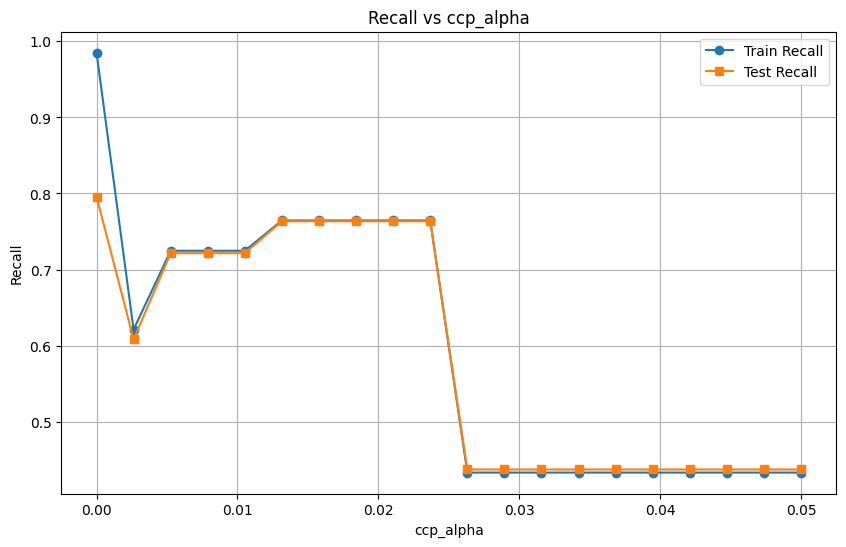

In [248]:
plt.figure(figsize=(10,6))
plt.plot(ccp_alpha_values, train_recall_scores, marker='o', label='Train Recall')
plt.plot(ccp_alpha_values, test_recall_scores, marker='s', label='Test Recall')
plt.xlabel('ccp_alpha')
plt.ylabel('Recall')
plt.title('Recall vs ccp_alpha')
plt.legend()
plt.grid(True)
plt.show()

In [249]:
dtree3 = best_estimator_recall

dtree3.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.013157894736842105, random_state=42)

**Train**

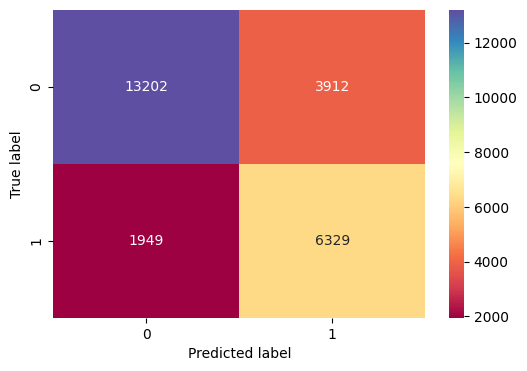

In [251]:
confusion_matrix_Decision_sklearn(dtree3, X_train, y_train)

In [252]:
decision_tree_post_prune_perf_train = model_performance_DecisionTree_sklearn(dtree3, X_train, y_train)
decision_tree_post_prune_perf_train

,Accuracy,Recall,Precision,F1
0,0.769179,0.764557,0.618006,0.683514


**Test**

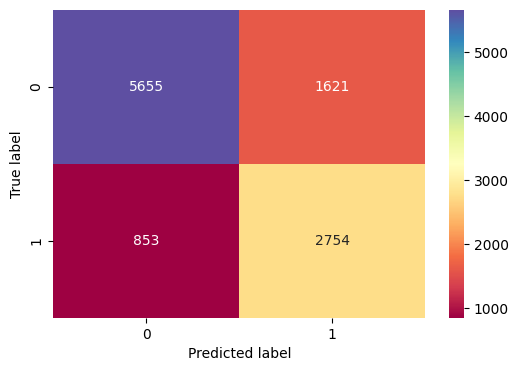

In [254]:
confusion_matrix_Decision_sklearn(dtree3, X_test, y_test)

In [255]:
decision_tree_post_prune_perf_test = model_performance_DecisionTree_sklearn(dtree3, X_test, y_test)
decision_tree_post_prune_perf_test

,Accuracy,Recall,Precision,F1
0,0.772673,0.763515,0.629486,0.690053


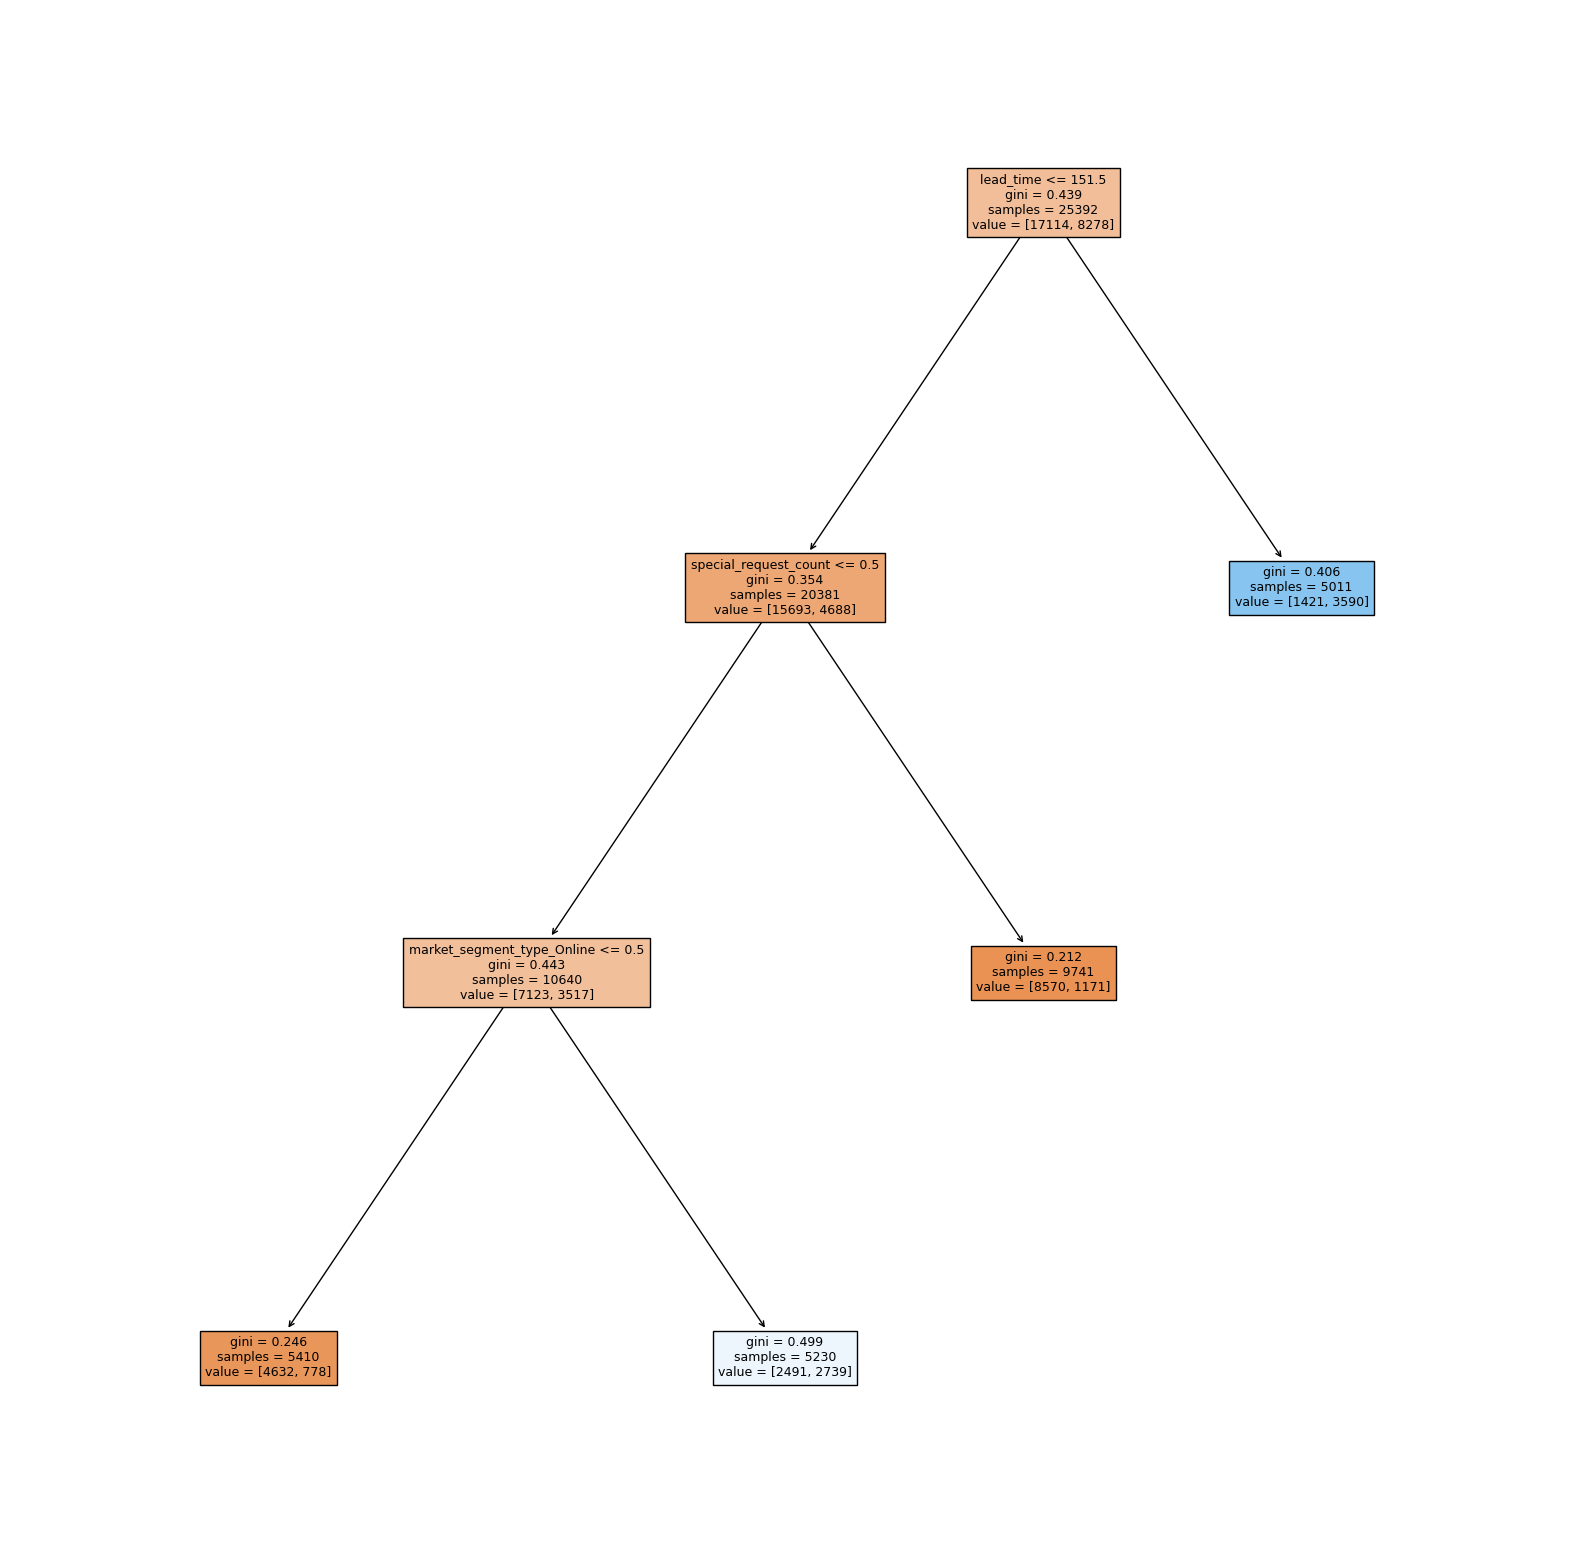

In [256]:
feature_names = list(X_train.columns)

plt.figure(figsize=(20, 20))

out = tree.plot_tree(
    dtree3,
    feature_names=feature_names,   
    filled=True,                    
    fontsize=9,                    
    node_ids=False,                 
    class_names=None,              
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")    
        arrow.set_linewidth(1)         

plt.show()

In [257]:
feature_names = list(X_train.columns)
print(
    tree.export_text(
        dtree3,
        feature_names=feature_names,    
        show_weights=True  
    )
)

|--- lead_time <= 151.50
|   |--- special_request_count <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- weights: [4632.00, 778.00] class: 0
|   |   |--- market_segment_type_Online >  0.50
|   |   |   |--- weights: [2491.00, 2739.00] class: 1
|   |--- special_request_count >  0.50
|   |   |--- weights: [8570.00, 1171.00] class: 0
|--- lead_time >  151.50
|   |--- weights: [1421.00, 3590.00] class: 1



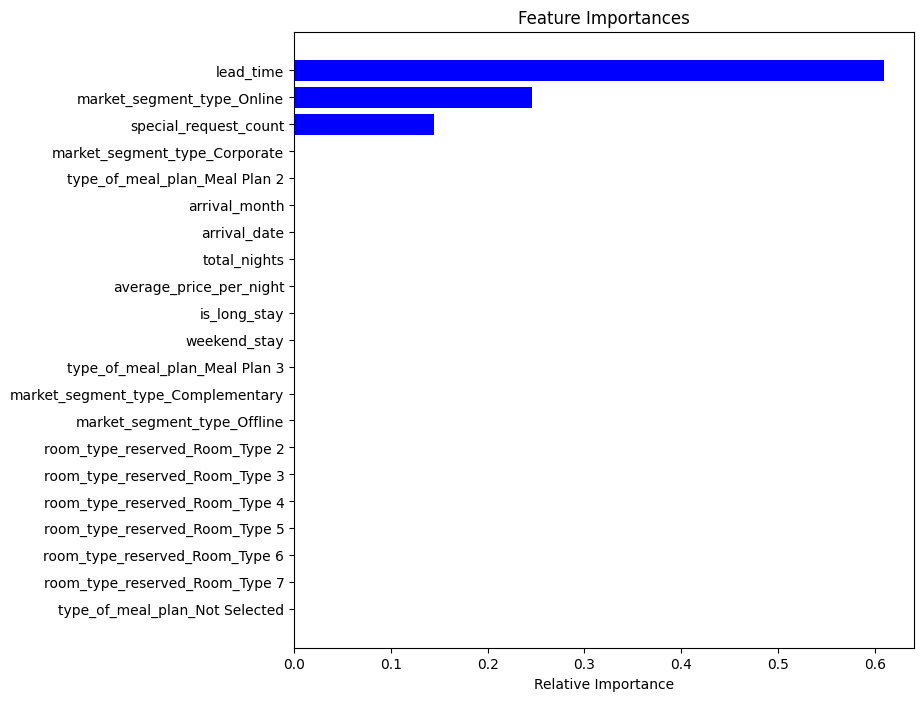

In [258]:
importances = dtree3.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="blue", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

1)	lead_time
           Most important by far (almost 50% relative importance).
    (Typically, bookings made far in advance have higher chances of cancellation.)
 
2)	market_segment_type_Online
Online bookings are the second biggest factor.
Online customers might behave differently — more flexible to cancel compared to walk-ins or corporate bookings.


3)	special_request_count
 Special requests (like extra beds, late checkouts) are important too.
Customers who make special requests might be more serious about showing up, or very selective.


### Training Comparison of Decision Tree (Sklearn)

In [261]:
models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_train.T,
        decision_tree_pre_prune_perf_train.T,
        decision_tree_post_prune_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Default (Sklearn)",
    "Decision Tree Pre-pruning",
    "Decision Tree Post-pruning",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Decision Tree Default (Sklearn),Decision Tree Pre-pruning,Decision Tree Post-pruning
Accuracy,0.993778,0.830734,0.769179
Recall,0.984900,0.801160,0.764557
Precision,0.995969,0.714347,0.618006
F1,0.990403,0.755267,0.683514


#### **Insights (Training):**

**Decision Tree Default (Sklearn):**
- Extremely high accuracy (99.38%), recall (98.49%), and precision (99.60%).
- F1 = 99.04% near perfect.
- Precision = 99.6%

On training data, there is a high likelihood of overfitting; this may not translate well to test data.

**Decision Tree Pre-pruning:**
- Accuracy = 83.07% 
- Recall = 80.11%
- Precision = 71.14%
- F1 = 76% balanced but moderate performance.

Pre-pruning helps to control complexity and avoid overfitting.

**Decision Tree Post-pruning:**
- Accuracy = 76.9%, similar to pre-pruning.
- Recall = 76.4%.
- F1 = 68.3% balanced, slightly lower than pre-pruning.
- Precision = 61.80%

Post-pruning also reduces overfitting, though it may slightly reduce recall.

### Test Comparison of Logistic Regression (Stats)

In [264]:
models_train_comp_df = pd.concat(
    [
        decision_tree_default_perf_test.T,
        decision_tree_pre_prune_perf_test.T,
        decision_tree_post_prune_perf_test.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree Default (Sklearn)",
    "Decision Tree Pre-pruning",
    "Decision Tree Post-pruning",
]
print("Test performance comparison:")
models_train_comp_df

Test performance comparison:


,Decision Tree Default (Sklearn),Decision Tree Pre-pruning,Decision Tree Post-pruning
Accuracy,0.860976,0.833318,0.772673
Recall,0.795952,0.799279,0.763515
Precision,0.787007,0.725648,0.629486
F1,0.791454,0.760686,0.690053


#### **Insights (Test):**

**Decision Tree Default (Sklearn):**
- Accuracy = 86%, strong performance on test data.
- Recall = 79.75%, Precision = 78.7% has good balance
- F1 = 79.01%

Despite strong metrics, it may still be slightly overfitting given the large drop from perfect training scores.

**Decision Tree Pre-pruning:**
- Accuracy = 83.33% balanced.
- Recall = 79.27%
- F1 = 76.06 moderate, with slightly better balance than post-pruning.
- Precision = 72.56

Reduced overfitting compared to the default tree.

**Decision Tree Post-pruning:**
- Accuracy = 77.26%, comparable to pre-pruning.
- Recall = 76.35%, Precision = 63%
- F1 = 69%, just below pre-pruning.

Helps keep the model simpler, at the slight cost of performance.

# <a name=link4>Model Performance Comparison and Final Model Selection</a>

## Training Comparison 

In [268]:
models_train_comp_df = pd.concat(
    [
        lg1_perf_train.T,
        lg1_perf_train1.T,
        decision_tree_default_perf_train.T,
        decision_tree_pre_prune_perf_train.T,
        decision_tree_post_prune_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Model Default (Stats)",
    "Logistic Model Threshold of 0.29",
    "Decision Tree Default (Sklearn)",
    "Decision Tree Pre-pruning",
    "Decision Tree Post-pruning",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Model Default (Stats),Logistic Model Threshold of 0.29,Decision Tree Default (Sklearn),Decision Tree Pre-pruning,Decision Tree Post-pruning
Accuracy,0.788792,0.793321,0.993778,0.830734,0.769179
Recall,0.584078,0.533511,0.984900,0.801160,0.764557
Precision,0.715766,1.000000,0.995969,0.714347,0.618006
F1,0.643252,0.695803,0.990403,0.755267,0.683514


## Test Comparison

In [433]:
models_train_comp_df = pd.concat(
    [
        lg1_perf_test.T,
        lg1_perf_test1.T,
        decision_tree_default_perf_test.T,
        decision_tree_pre_prune_perf_test.T,
        decision_tree_post_prune_perf_test.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Model Default (Stats)",
    "Logistic Model Threshold of 0.29",
    "Decision Tree Default (Sklearn)",
    "Decision Tree Pre-pruning",
    "Decision Tree Post-pruning",
]
print("Test performance comparison:")
models_train_comp_df

Test performance comparison:


,Logistic Model Default (Stats),Logistic Model Threshold of 0.29,Decision Tree Default (Sklearn),Decision Tree Pre-pruning,Decision Tree Post-pruning
Accuracy,0.790499,0.834696,0.860976,0.833318,0.772673
Recall,0.579706,0.590298,0.795952,0.799279,0.763515
Precision,0.732399,1.000000,0.787007,0.725648,0.629486
F1,0.647168,0.742374,0.791454,0.760686,0.690053


## Insights

### **Logistic Regression (Default Threshold 0.5)**
**Training Performance:** Moderate performance across all metrics.

**Test Performance:** Accuracy and precision are good, but recall is slightly lower.

**Observation:** Balanced but not the best performer. Slight underfitting.

### **Logistic Regression (Threshold = 0.29)**
**Training Performance:** Improvement in all metrics after adjusting threshold.

**Test Performance:** - Highest accuracy (83%), Recall (59%) and F1 score (74%). 
                      - Perfect precision (1.0), suggesting zero false positives
                      
**Observation:** A well-defined threshold significantly improves performance while avoiding overfitting.

### **Decision Tree (Default - Sklearn)**

**Training Performance:** Extremely high across the board. Likely overfitting.

**Test Performance:** - High recall (86%) and good F1 score (79%). - Accuracy is decent but lower than logistic with threshold.
                      
**Observation:** Performs very well but tends to overfit, evident from the large drop from training to test scores.

### **Decision Tree (Pre-pruning)**
**Training Performance:** Regularized, more balanced.

**Test Performance:** Metrics are improved compared to post-pruning but still less than other models.

**Observation:** Pruning helps avoid overfitting but reduces overall effectiveness.

### **Decision Tree (Post-pruning)**
**Training Performance:** Consistently lower recall and F1 scores.

**Test Performance:** Consistently lower recall and F1 scores.

**Observation:** Excessive regularization may have reduced model capacity too much.




## Model Recommendation
### **Decision Tree (Pre-pruning)**

- High Recall (80%) → Catches cancellations better than Logistic Regression (important for business).
  
- Good Precision (73%) → Reasonably few false alarms.
  
- F1 Score is Higher (76%) → Balanced metric (better than Logistic Model at threshold 0.29).
  
- Generalized Model → Pre-pruning prevents overfitting compared to default decision tree.

**Overall, the Decision Tree Pre-pruning is more balanced, robust, and practical for deployment.**


# <a name=link5>Actionable Insights & Recommendations</a>

## Actionable Insights

- Lead Time is the most influential factor affecting customer behavior.

- Market Segment Type (Online) bookings play a major role in customer outcomes.

- Special Request Count has a strong impact on guest satisfaction and booking retention.

- Average Price Per Night affects customer decision-making significantly.

- Arrival Month influences booking patterns and customer behavior.

- Weekend Stay and Long Stay factors have minor, but notable, effects.

- Corporate Market Segment shows measurable but smaller influence compared to online bookings.

## Recommendations

1.	**Optimize Lead Time:**
    - For moderate lead times, offer early discounts.
    - Introduce flexible cancellation policies for very early bookings.
2.	**Enhance Online Booking Experience:**
    - Improve website/app UX/UI.
3.	**Personalize Services Based on Special Requests:**
    - Prioritize fulfilling special requests to improve guest experience.
    - Offer customizable add-on packages during the booking process.
4.	**Implement Smart Pricing Strategies:**
    - Bundle services (e.g., breakfast, spa) instead of just offering discounts.
5.	**Leverage Seasonality (Arrival Month):**
    - Design seasonal offers for low-demand months.
    - Adjust staffing and inventory in advance based on forecasted demand.
6.	**Encourage Weekend and Long Stays:**
    - Offer weekend getaway packages.
    - Provide discounted rates for longer stays, especially during off-peak periods.
